In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Any
import json

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from labellines import labelLines

from google import genai

from IPython.display import display
import textwrap
def wrap(text, width=100):
    print('\n'.join(textwrap.wrap(text, width)))
    
import yaml

from pydantic import BaseModel, Field

from typing import Literal
from openai import OpenAI

import statsmodels.api as sm
import statsmodels.formula.api as smf

import sys
import os

sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../..'))

from apa_style import set_apa_style, get_figsize, format_axes_labels
set_apa_style()
import matplotx
from apa_style import APA_STYLE

def load_events(results_file: str | Path) -> pd.DataFrame:
    """Load events.jsonl file into a single DataFrame."""
    path = Path(results_file)
    if results_file.stem[0]=='_':
        return
    frames = []
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line]
    if rows:
        frames.append(pd.DataFrame(rows))
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    return df

def load_all_events(results_files: list) -> pd.DataFrame:
    all_dfs = []
    for rf in results_files:
        temp_df = load_events(rf)
        all_dfs.append(temp_df)
    return pd.concat(all_dfs, ignore_index=True)


def _load_analysis_config(config: dict[str, Any] | str | Path | None) -> dict[str, Any] | None:
    if config is None or isinstance(config, dict):
        return config
    path = Path(config)
    text = path.read_text(encoding="utf-8")
    if path.suffix.lower() == ".json":
        return json.loads(text)
    return yaml.safe_load(text)

def calculate_effective_unit_cost(row):
    # Base facts about the options (5 bags)
    bags = 5
    price_a = 4.99 * bags
    grams_a = 340 * bags
    
    price_b = 5.00 * bags
    grams_b = 420 * bags
    
    # Extract agent's path
    num_clicks = row['num_tool_calls']
    cost_per_click = row['inspect_cell_tool_cost']
    total_search_cost = num_clicks * cost_per_click
    
    # Calculate numerator and denominator based on final choice
    if row['choice'] == 'coffee_a':
        total_spent = price_a + total_search_cost
        total_grams = grams_a
    elif row['choice'] == 'coffee_b':
        total_spent = price_b + total_search_cost
        total_grams = grams_b
    else:
        # Penalize agents that failed to make a choice
        return None 
        
    # The DV: Effective Cost per Gram
    effective_unit_cost = total_spent / total_grams

    return effective_unit_cost


def calculate_effective_unit_cost_worst(row):
    # Base facts about the options (5 bags)
    bags = 5
    price_a = 4.99 * bags
    grams_a = 340 * bags
    
    cost_per_click = row['inspect_cell_tool_cost']

    # worst case
    num_clicks_worst = 7 * 2
    total_search_cost_worst = num_clicks_worst * cost_per_click
    total_spent_worst = price_a + total_search_cost_worst
    total_grams_worst = grams_a
    effective_unit_cost_worst = total_spent_worst / total_grams_worst

    return effective_unit_cost_worst

def get_data():
    results_files = list(results_dir.glob('*-events.jsonl'))
    config_files = list(results_dir.glob('*-config.json'))
    config_file = config_files[0] if config_files else None
    config = _load_analysis_config(config_file)
    metadata_columns = list(config['metadata'].keys())
    # print('metadata_columns', metadata_columns)

    df_raw = load_all_events(results_files)
    df = df_raw.copy().sort_values(['session_name', 'step_index'])
    meta_df = df['meta'].dropna().apply(pd.Series)
    meta_df = meta_df.add_prefix('meta_')
    if not meta_df.empty:
        df = df.join(meta_df)

    meta_cols = df.filter(like='meta_').columns
    df[meta_cols] = df.groupby('session_name')[meta_cols].ffill()
    return df, config

exp_name = 'study2-leftdigit-5bags'

results_dir = Path('/home/dw/github/toollab/results/')/exp_name

df, config = get_data()
# print(f"{len(df)} events across {df['session_name'].nunique()} sessions")
# print(df[['option_count', 'design']])
print(df.columns)
print(df.shape)

df.groupby(['model_name', 'prompt_type','inspect_cell_tool_cost' ])['session_name'].nunique()

Index(['session_name', 'experiment_name', 'provider', 'model_name',
       'forced_choice', 'choice', 'budget_type', 'budget_max',
       'cumulative_cost_usd', 'budget_remaining_usd', 'cumulative_cost_tools',
       'budget_remaining_tools', 'cumulative_cost_tool_usd',
       'cumulative_cost_tokens', 'budget_remaining_tokens',
       'cumulative_cost_points', 'budget_remaining_points', 'option_count',
       'prompt_type', 'option_mapping', 'started_at', 'finished_at',
       'system_prompt', 'user_message', 'inspect_cell_tool_cost', 'step_index',
       'kind', 'content', 'reasoning', 'input_tokens', 'output_tokens',
       'input_cost', 'output_cost', 'tool_cost', 'point_cost', 'tool_usd_cost',
       'tool_calls', 'finish_reason', 'meta', 'tool_name', 'tool_call_id',
       'option_id', 'attribute_id', 'result', 'turn_cost_usd', 'is_revisit',
       'transition', 'confidence_score', 'most_important_attribute',
       'meta_thinking_level'],
      dtype='object')
(46450, 50)


model_name                     prompt_type     inspect_cell_tool_cost
gemini-3-flash-preview         deal            0.0                       100
                                               0.5                       100
                                               1.0                       100
                                               2.0                       100
                                               5.0                       100
                                               10.0                      100
                               value_function  0.0                       100
                                               0.5                       100
                                               1.0                       100
                                               2.0                       100
                                               5.0                       100
                                               10.0                      100
gemini

In [145]:
df = df[df['model_name']!='gemini-3-flash-preview']

### Effective cost and optimal plots

In [69]:
df, config = get_data()

df['is_optimal'] = (df['choice']=='coffee_b').astype(int)
def get_price_dollars(choice):
    cue = [c for c in config['cues'] if (c['option_id']==choice and c['attribute_id']=='price_dollars')][0]
    return cue['value']

df['choice_price_dollars'] = df['choice'].apply(get_price_dollars)

df_session_list = []
for session_name, session in df.groupby('session_name'):

    # display((session))
    inspect_cell_tool_cost = session['inspect_cell_tool_cost'].iloc[0]
    prompt_type = session['prompt_type'].iloc[0]
    model_name = session['model_name'].iloc[0]
    choice = session['choice'].iloc[0]
    choice_price_dollars = session['choice_price_dollars'].iloc[0]
    is_optimal = session['is_optimal'].iloc[0]

    # print(session.columns)
    subset_tools = session[session['tool_name']=='inspect_cell']
    # display(subset_tools.columns)
    tools_called = subset_tools['attribute_id'].unique().tolist()
    called_cents = int('price_cents' in tools_called)
    num_tool_calls = len(subset_tools)
    # print(tools_called)
    
    df_session_list.append({
        'session_name': session_name,
        'inspect_cell_tool_cost': session['inspect_cell_tool_cost'].iloc[0],
        'prompt_type':prompt_type,
        'model_name': session['model_name'].iloc[0],
        'choice': session['choice'].iloc[0],
        'choice_price_dollars': session['choice_price_dollars'].iloc[0],
        'is_optimal': session['is_optimal'].iloc[0],
        'called_cents':called_cents, 
        'tools_called': tools_called,
        'num_tool_calls':num_tool_calls,
    })
    
df_session = pd.DataFrame(df_session_list)
# df_session.groupby(['model_name', 'prompt_type','inspect_cell_tool_cost', ])['is_optimal'].mean()
df_session['Effective_Cost_Per_Gram'] = df_session.apply(calculate_effective_unit_cost, axis=1)
df_session['Effective_Cost_Per_KG'] = df_session['Effective_Cost_Per_Gram']*1000

# cap to 100 per cell
df_session = df_session.groupby(
    ['model_name', 'prompt_type', 'inspect_cell_tool_cost']
).head(100)

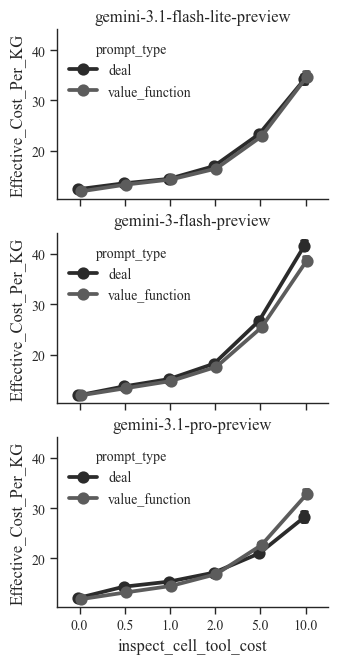

In [70]:
models = [
    'gemini-3.1-flash-lite-preview', 
    'gemini-3-flash-preview',
    'gemini-3.1-pro-preview',
]
prompt_types = df_session['prompt_type'].unique()
tool_costs = df_session['inspect_cell_tool_cost'].unique()

nrows = 3
ncols = 1

fig, axes = plt.subplots(len(models),1, figsize=get_figsize(nrows, ncols), sharex=True, sharey=True)
for model, ax in zip(models, axes):
    subset = df_session[df_session['model_name']==model]
    # display(subset)
    sns.pointplot(
        data=subset, 
        x='inspect_cell_tool_cost', 
        y='Effective_Cost_Per_KG', 
        hue='prompt_type',
        dodge=True,      # Slightly offsets the lines so they don't overlap perfectly
        capsize=.1,
        ax=ax
    )
    ax.set_title(model)
    # break

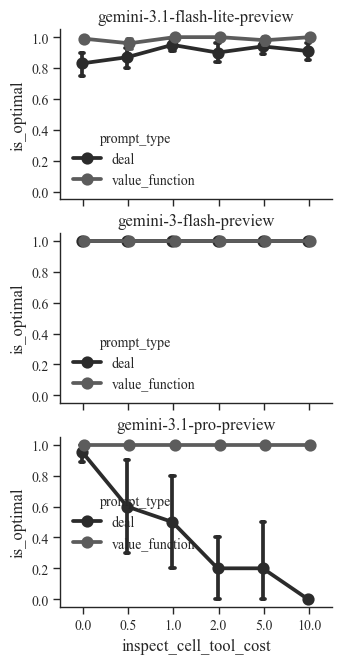

In [50]:
models = [
    'gemini-3.1-flash-lite-preview', 
    'gemini-3-flash-preview',
    'gemini-3.1-pro-preview',
]
prompt_types = df_session['prompt_type'].unique()
tool_costs = df_session['inspect_cell_tool_cost'].unique()

nrows = 3
ncols = 1

fig, axes = plt.subplots(len(models),1, figsize=get_figsize(nrows, ncols), sharex=True, sharey=True)
for model, ax in zip(models, axes):
    subset = df_session[df_session['model_name']==model]
    # display(subset)
    sns.pointplot(
        data=subset, 
        x='inspect_cell_tool_cost', 
        y='is_optimal', 
        hue='prompt_type',
        dodge=True,      # Slightly offsets the lines so they don't overlap perfectly
        capsize=.1,
        ax=ax
    )
    ax.set_title(model)
    # break

### Some plots

<Axes: xlabel='inspect_cell_tool_cost', ylabel='called_cents'>

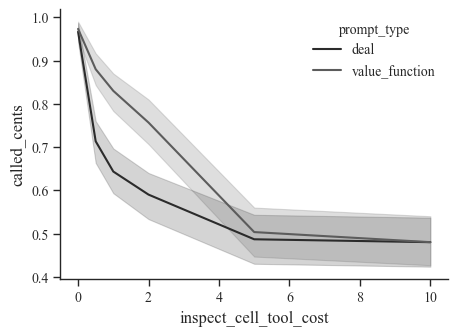

In [71]:
sns.lineplot(
    data=df_session,
    x = 'inspect_cell_tool_cost',
    y = 'called_cents',
    hue = 'prompt_type',
)

In [72]:
# Ensure your variables are formatted correctly
# We convert categorical variables into 'category' type so we can set references
df_session['prompt_type_cat'] = df_session['prompt_type'].astype('category')
df_session['model_name_cat'] = df_session['model_name'].astype('category')

# Set the reference levels as requested
df_session['prompt_type_cat'] = df_session['prompt_type_cat'].cat.reorder_categories(['deal', 'value_function'], ordered=False)
# Ensure your exact model string matches the one in your dataframe
df_session['model_name_cat'] = df_session['model_name_cat'].cat.reorder_categories(['gemini-3.1-flash-lite-preview', 'gemini-3-flash-preview', 'gemini-3.1-pro-preview'], ordered=False) 

# Formula: is_optimal is predicted by prompt_type, model_name, and cost
# C() tells the model these are Categorical variables
model = smf.logit(
    "is_optimal ~ C(prompt_type_cat) + C(model_name_cat) + inspect_cell_tool_cost", 
    data=df_session
).fit_regularized(method='l1', alpha=1.0) 

print(model.summary())


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.1794063759670374
            Iterations: 70
            Function evaluations: 70
            Gradient evaluations: 70
                           Logit Regression Results                           
Dep. Variable:             is_optimal   No. Observations:                 3600
Model:                          Logit   Df Residuals:                     3595
Method:                           MLE   Df Model:                            4
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.5256
Time:                        08:24:44   Log-Likelihood:                -631.31
converged:                       True   LL-Null:                       -1330.9
Covariance Type:            nonrobust   LLR p-value:                1.083e-301
                                                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

/home/dw/github/toollab/.venv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,
/home/dw/github/toollab/.venv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1577: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanquantile_1d, axis, a, q,


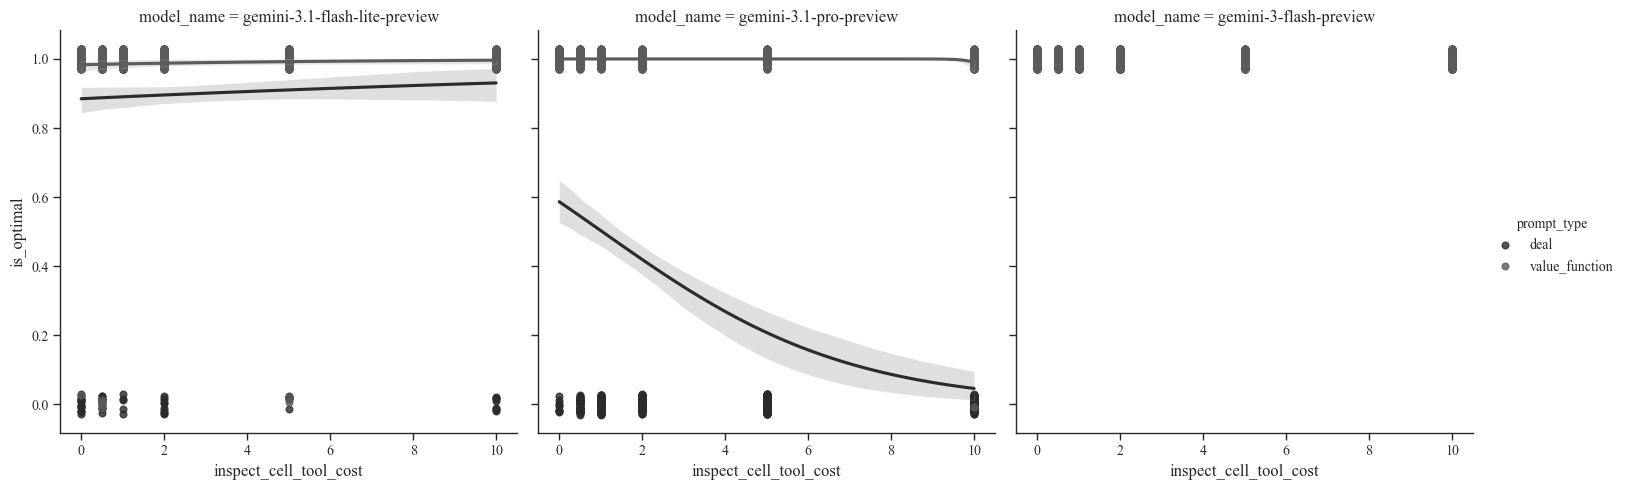

In [73]:
plot_df = df_session

sns.lmplot(
    data=plot_df, 
    x='inspect_cell_tool_cost', 
    y='is_optimal', 
    hue='prompt_type', 
    col='model_name',
    logistic=True, # This draws the S-curve of probability
    y_jitter=0.03,  # Makes the 0s and 1s easier to see
)

# the effect of constraint on choice

### max steps taken

<Axes: xlabel='model_name', ylabel='num_inspect'>

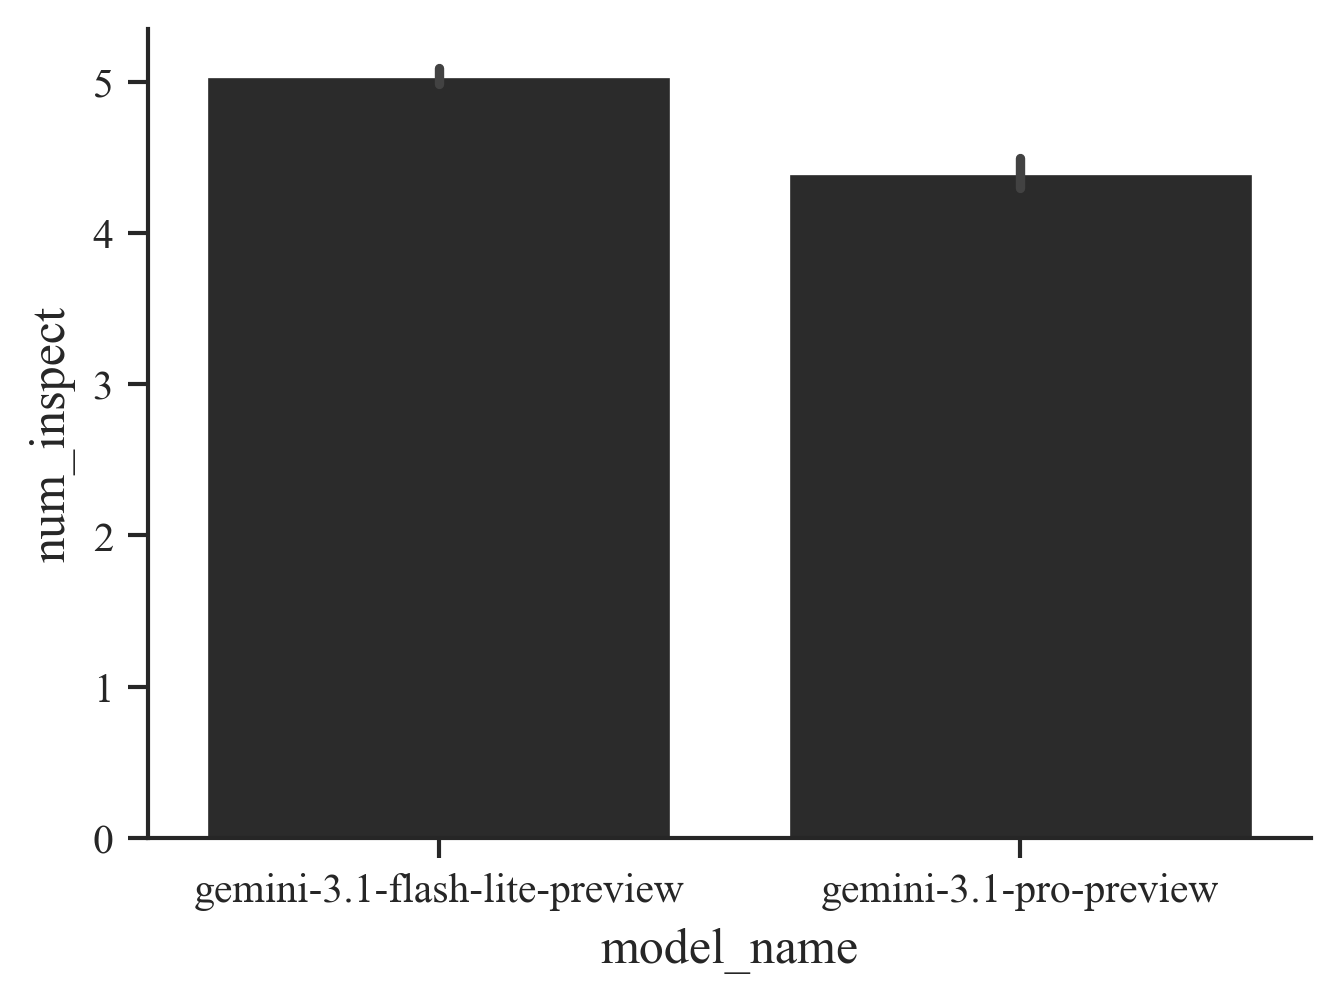

In [177]:
df, config = get_data()

df = df[df['model_name']!='gemini-3-flash-preview']


df_copy = df.copy()
df_copy['is_inspect'] = df_copy['tool_name'] == 'inspect_cell'

num_inspect = df_copy.groupby('session_name').agg({
    'model_name':'first',
    'is_inspect': 'sum',
})
num_inspect = num_inspect.rename({'is_inspect':'num_inspect'}, axis=1)
# num_inspect.plot(kind='bar', x = 'budget_max', y='is_inspect')
sns.barplot(data=num_inspect, x = 'model_name', y = 'num_inspect')

#### Resource rational analysis

### Reasoning

In [184]:
df, config = get_data()

gemini_pro = df[df['model_name']=='gemini-3.1-flash-lite-preview']
reasoning_traces = []
for index, (session_name, subset) in enumerate(gemini_pro.groupby('session_name')):
    print(index, session_name, subset['inspect_cell_tool_cost'].max())
    if (index+1)<len(gemini_pro.groupby('session_name')): continue
    assistant = subset[subset['kind']=='assistant']
    reasoning_trace_list = []
    for step, (i, row) in enumerate(assistant.iterrows(), 1):
        print(i)
        reasoning = row['reasoning']
        tc = subset.loc[i+1,['attribute_id', 'result', 'tool_name', 'cumulative_cost_tool_usd']]
        wrap(reasoning)
        reasoning_trace_list.append(f"Reasoning Step {step}:\n{reasoning.strip()}")
        reasoning_trace_list.append('-'*50)
        if tc['tool_name']=='inspect_cell':
            display(tc)
            reasoning_trace_list.append(f"Tool Response Step {step}:\n{tc.to_string().strip()}")
            reasoning_trace_list.append('-'*50)

        else:
            print()
            print(f"Choice: {row['choice']}, most_important_attribute: {subset.loc[i+1, 'most_important_attribute']}")
            reasoning_trace_list.append(f"Choice: {row['choice']}")

        # break
    full_trace = '\n\n'.join(reasoning_trace_list)
    reasoning_traces.append({
        'session_name': session_name,
        'full_trace': full_trace,
    })
    # display(assistant)
    # break
    print('+'*50)

0 20260420T150657978809Z 0.0
1 20260420T150705606229Z 0.5
2 20260420T150713184997Z 1.0
3 20260420T150720548047Z 2.0
4 20260420T150753752179Z 0.0
5 20260420T150759901309Z 0.0
6 20260420T150805952281Z 0.0
7 20260420T150812295329Z 0.0
8 20260420T150820998622Z 0.0
9 20260420T150826754643Z 0.0
10 20260420T150834085666Z 0.0
11 20260420T150841326797Z 0.0
12 20260420T150846675111Z 0.0
13 20260420T150852207793Z 0.5
14 20260420T150856048084Z 0.5
15 20260420T150900932968Z 0.5
16 20260420T150906459150Z 0.5
17 20260420T150911280556Z 0.5
18 20260420T150916319686Z 0.5
19 20260420T150924204345Z 0.5
20 20260420T150930386796Z 0.5
21 20260420T150934679818Z 0.5
22 20260420T150939207925Z 1.0
23 20260420T150943249637Z 1.0
24 20260420T150950059850Z 1.0
25 20260420T150954058120Z 1.0
26 20260420T150959586791Z 1.0
27 20260420T151003775305Z 1.0
28 20260420T151011360807Z 1.0
29 20260420T151017286515Z 1.0
30 20260420T151026069755Z 1.0
31 20260420T151031425577Z 2.0
32 20260420T151036095858Z 2.0
33 20260420T15104165

attribute_id                price_dollars
result                                 $5
tool_name                    inspect_cell
cumulative_cost_tool_usd              0.0
Name: 14711, dtype: object

14712



attribute_id                 price_cents
result                           0 cents
tool_name                   inspect_cell
cumulative_cost_tool_usd             0.0
Name: 14713, dtype: object

14714



...

14718



attribute_id                 price_cents
result                          99 cents
tool_name                   inspect_cell
cumulative_cost_tool_usd             0.0
Name: 14719, dtype: object

14720



attribute_id                      weight
result                         340 grams
tool_name                   inspect_cell
cumulative_cost_tool_usd             0.0
Name: 14721, dtype: object

14722


Choice: coffee_b, most_important_attribute: price_per_gram
++++++++++++++++++++++++++++++++++++++++++++++++++


### Effective cost

In [178]:
session_records = []
for session_name, subset in df.groupby('session_name'):
    # print(session_name)
    inspect_cell_tool_cost = subset['inspect_cell_tool_cost'].iloc[0]
    prompt_type = subset['prompt_type'].iloc[0]
    tool_call_subset = subset[subset['tool_name']=='inspect_cell']
    attributes_checked = set(tool_call_subset['attribute_id'].unique())
    num_check_cents = (tool_call_subset['attribute_id']=='price_cents').sum()
    checked_cents = int('price_cents' in tool_call_subset['attribute_id'].values)
    num_inspect = len(tool_call_subset)

    submit_choice = subset[subset['tool_name']=='submit_choice']
    confidence_score = submit_choice['confidence_score'].iloc[0]
    final_choice = subset.choice.unique()[0]
    most_important_attribute = submit_choice['most_important_attribute'].iloc[0]
    
    tool_call_submit_choice = subset[subset['tool_calls'].str[0].str.get('name')=='submit_choice'].iloc[0]
    reasoning = tool_call_submit_choice['reasoning'] 
    
    session_records.append({
        'session_name': session_name,
        'model_name': subset.iloc[0]['model_name'],
        'inspect_cell_tool_cost': inspect_cell_tool_cost,
        'prompt_type': prompt_type,
        'num_tool_calls': num_inspect,
        'num_check_cents':num_check_cents,
        'checked_cents':checked_cents,
        'attributes_checked': list(attributes_checked),
        'choice': final_choice,
        'confidence_score': confidence_score,
        'most_important_attribute': most_important_attribute,
        'final_reasoning': reasoning
    })

session_df = pd.DataFrame(session_records)
# cap to 100 per cell
session_df = session_df.groupby(
    ['model_name', 'prompt_type', 'inspect_cell_tool_cost']
).head(100)

session_df['Effective_Cost_Per_Gram'] = session_df.apply(calculate_effective_unit_cost, axis=1)
session_df['Effective_Cost_Per_Gram_Worst'] = session_df.apply(calculate_effective_unit_cost_worst, axis=1)
session_df['Effective_Cost_Per_KG'] = session_df['Effective_Cost_Per_Gram']*1000
session_df['Effective_Cost_Per_KG_worst'] = session_df['Effective_Cost_Per_Gram_Worst']*1000


In [179]:
# 1. Apply your functions to create the columns (multiplying by 1000 to get per KG)
session_df['Effective_Cost_Per_KG'] = session_df.apply(calculate_effective_unit_cost, axis=1) * 1000
session_df['Worst_Case_Cost_Per_KG'] = session_df.apply(calculate_effective_unit_cost_worst, axis=1) * 1000
# Best case = 0 clicks (guessing correctly or $0 tool cost) and choosing Coffee B
session_df['Best_Case_Cost_Per_KG'] = (25.00 / (2100 / 1000)) # $11.90 / KG

In [183]:
session_df.columns
session_df.groupby(['model_name', 'inspect_cell_tool_cost'])['choice'].value_counts(normalize=True)

model_name                     inspect_cell_tool_cost  choice  
gemini-3.1-flash-lite-preview  0.0                     coffee_b    0.910
                                                       coffee_a    0.090
                               0.5                     coffee_b    0.915
                                                       coffee_a    0.085
                               1.0                     coffee_b    0.975
                                                       coffee_a    0.025
                               2.0                     coffee_b    0.950
                                                       coffee_a    0.050
                               5.0                     coffee_b    0.960
                                                       coffee_a    0.040
                               10.0                    coffee_b    0.955
                                                       coffee_a    0.045
gemini-3.1-pro-preview         0.0                     coffe

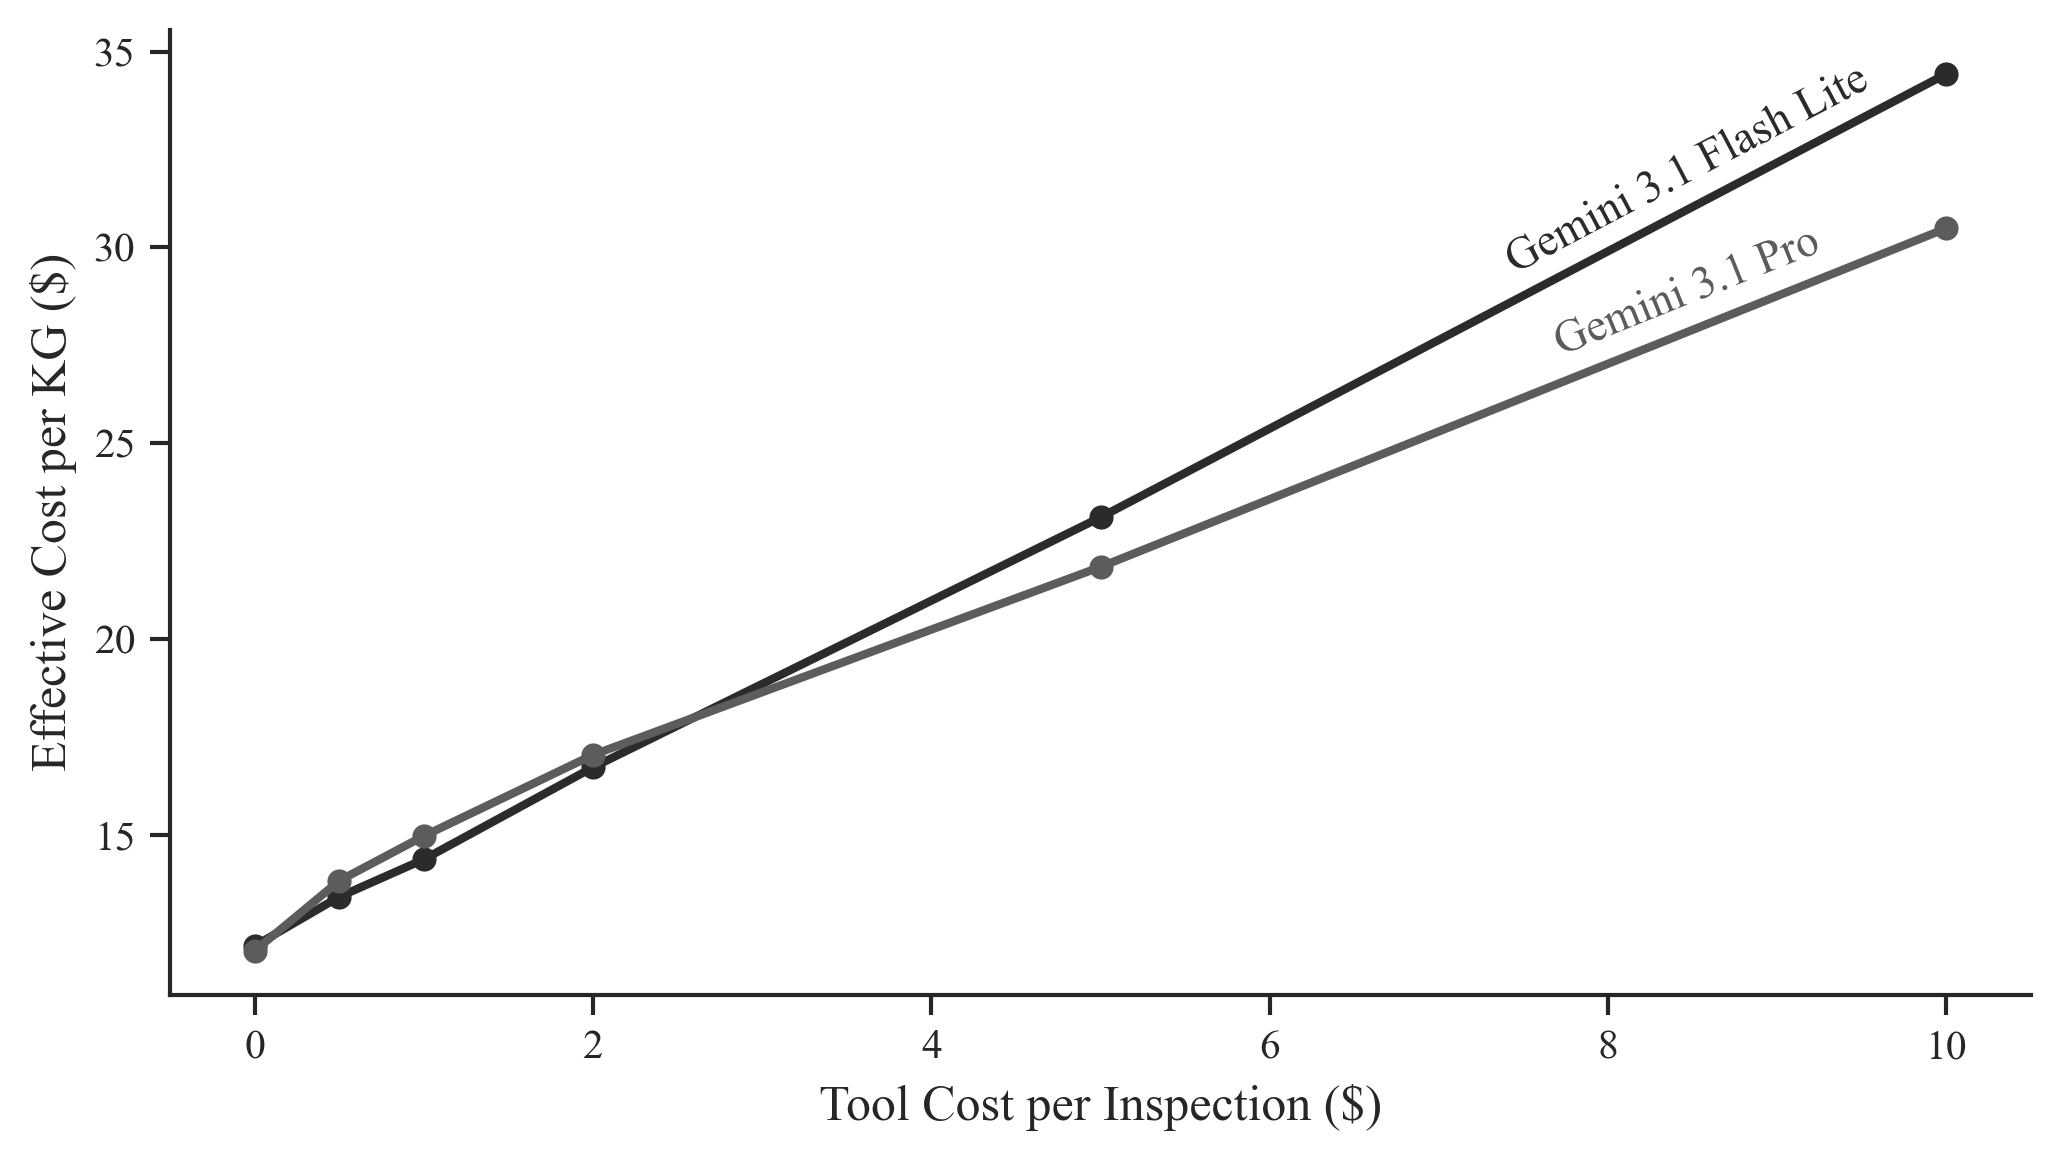

In [150]:

# --- Aggregate data per model ---
agg_df = (
    session_df
    .groupby(['inspect_cell_tool_cost', 'model_name'])
    .agg(
        Effective=('Effective_Cost_Per_KG', 'mean'),
        Worst=('Worst_Case_Cost_Per_KG', 'mean'),
        Best=('Best_Case_Cost_Per_KG', 'mean'),
    )
    .reset_index()
)

models = agg_df['model_name'].unique()

# --- Color cycle ---
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(figsize=(7, 4))

# --- Plot each model ---
for i, model in enumerate(models):
    mdf = agg_df[agg_df['model_name'] == model].sort_values('inspect_cell_tool_cost')
    ax.plot(
        mdf['inspect_cell_tool_cost'],
        mdf['Effective'],
        marker='o',
        linewidth=2,
        color=colors[i % len(colors)],
        label=model.replace('preview','').replace('-', ' ').title(),
    )

# --- Plot Worst / Best (use first model's x since they share x-axis) ---
# ref = agg_df[agg_df['model_name'] == models[0]].sort_values('inspect_cell_tool_cost')
# x_vals = ref['inspect_cell_tool_cost'].values

# ax.plot(x_vals, ref['Worst'].values,
#         marker='s', linewidth=2, linestyle='--',
#         color='red', label='Worst Case')

# ax.plot(x_vals, ref['Best'].values,
#         marker='s', linewidth=2, linestyle='--',
#         color='green', label='Best Case')

# --- Inline labels ---
all_lines = [
    l for l in ax.get_lines()
    if not l.get_label().startswith('_')
    and len(l.get_xdata()) > 1
]

labelLines(all_lines, xvals=8.5, outline_color='white', outline_width=2, yoffsets=1,zorder=2.5)

# --- Formatting ---
ax.set_ylabel("Effective Cost per KG ($)")
ax.set_xlabel("Tool Cost per Inspection ($)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

*Note.* The shaded regions denote the 95% CI.


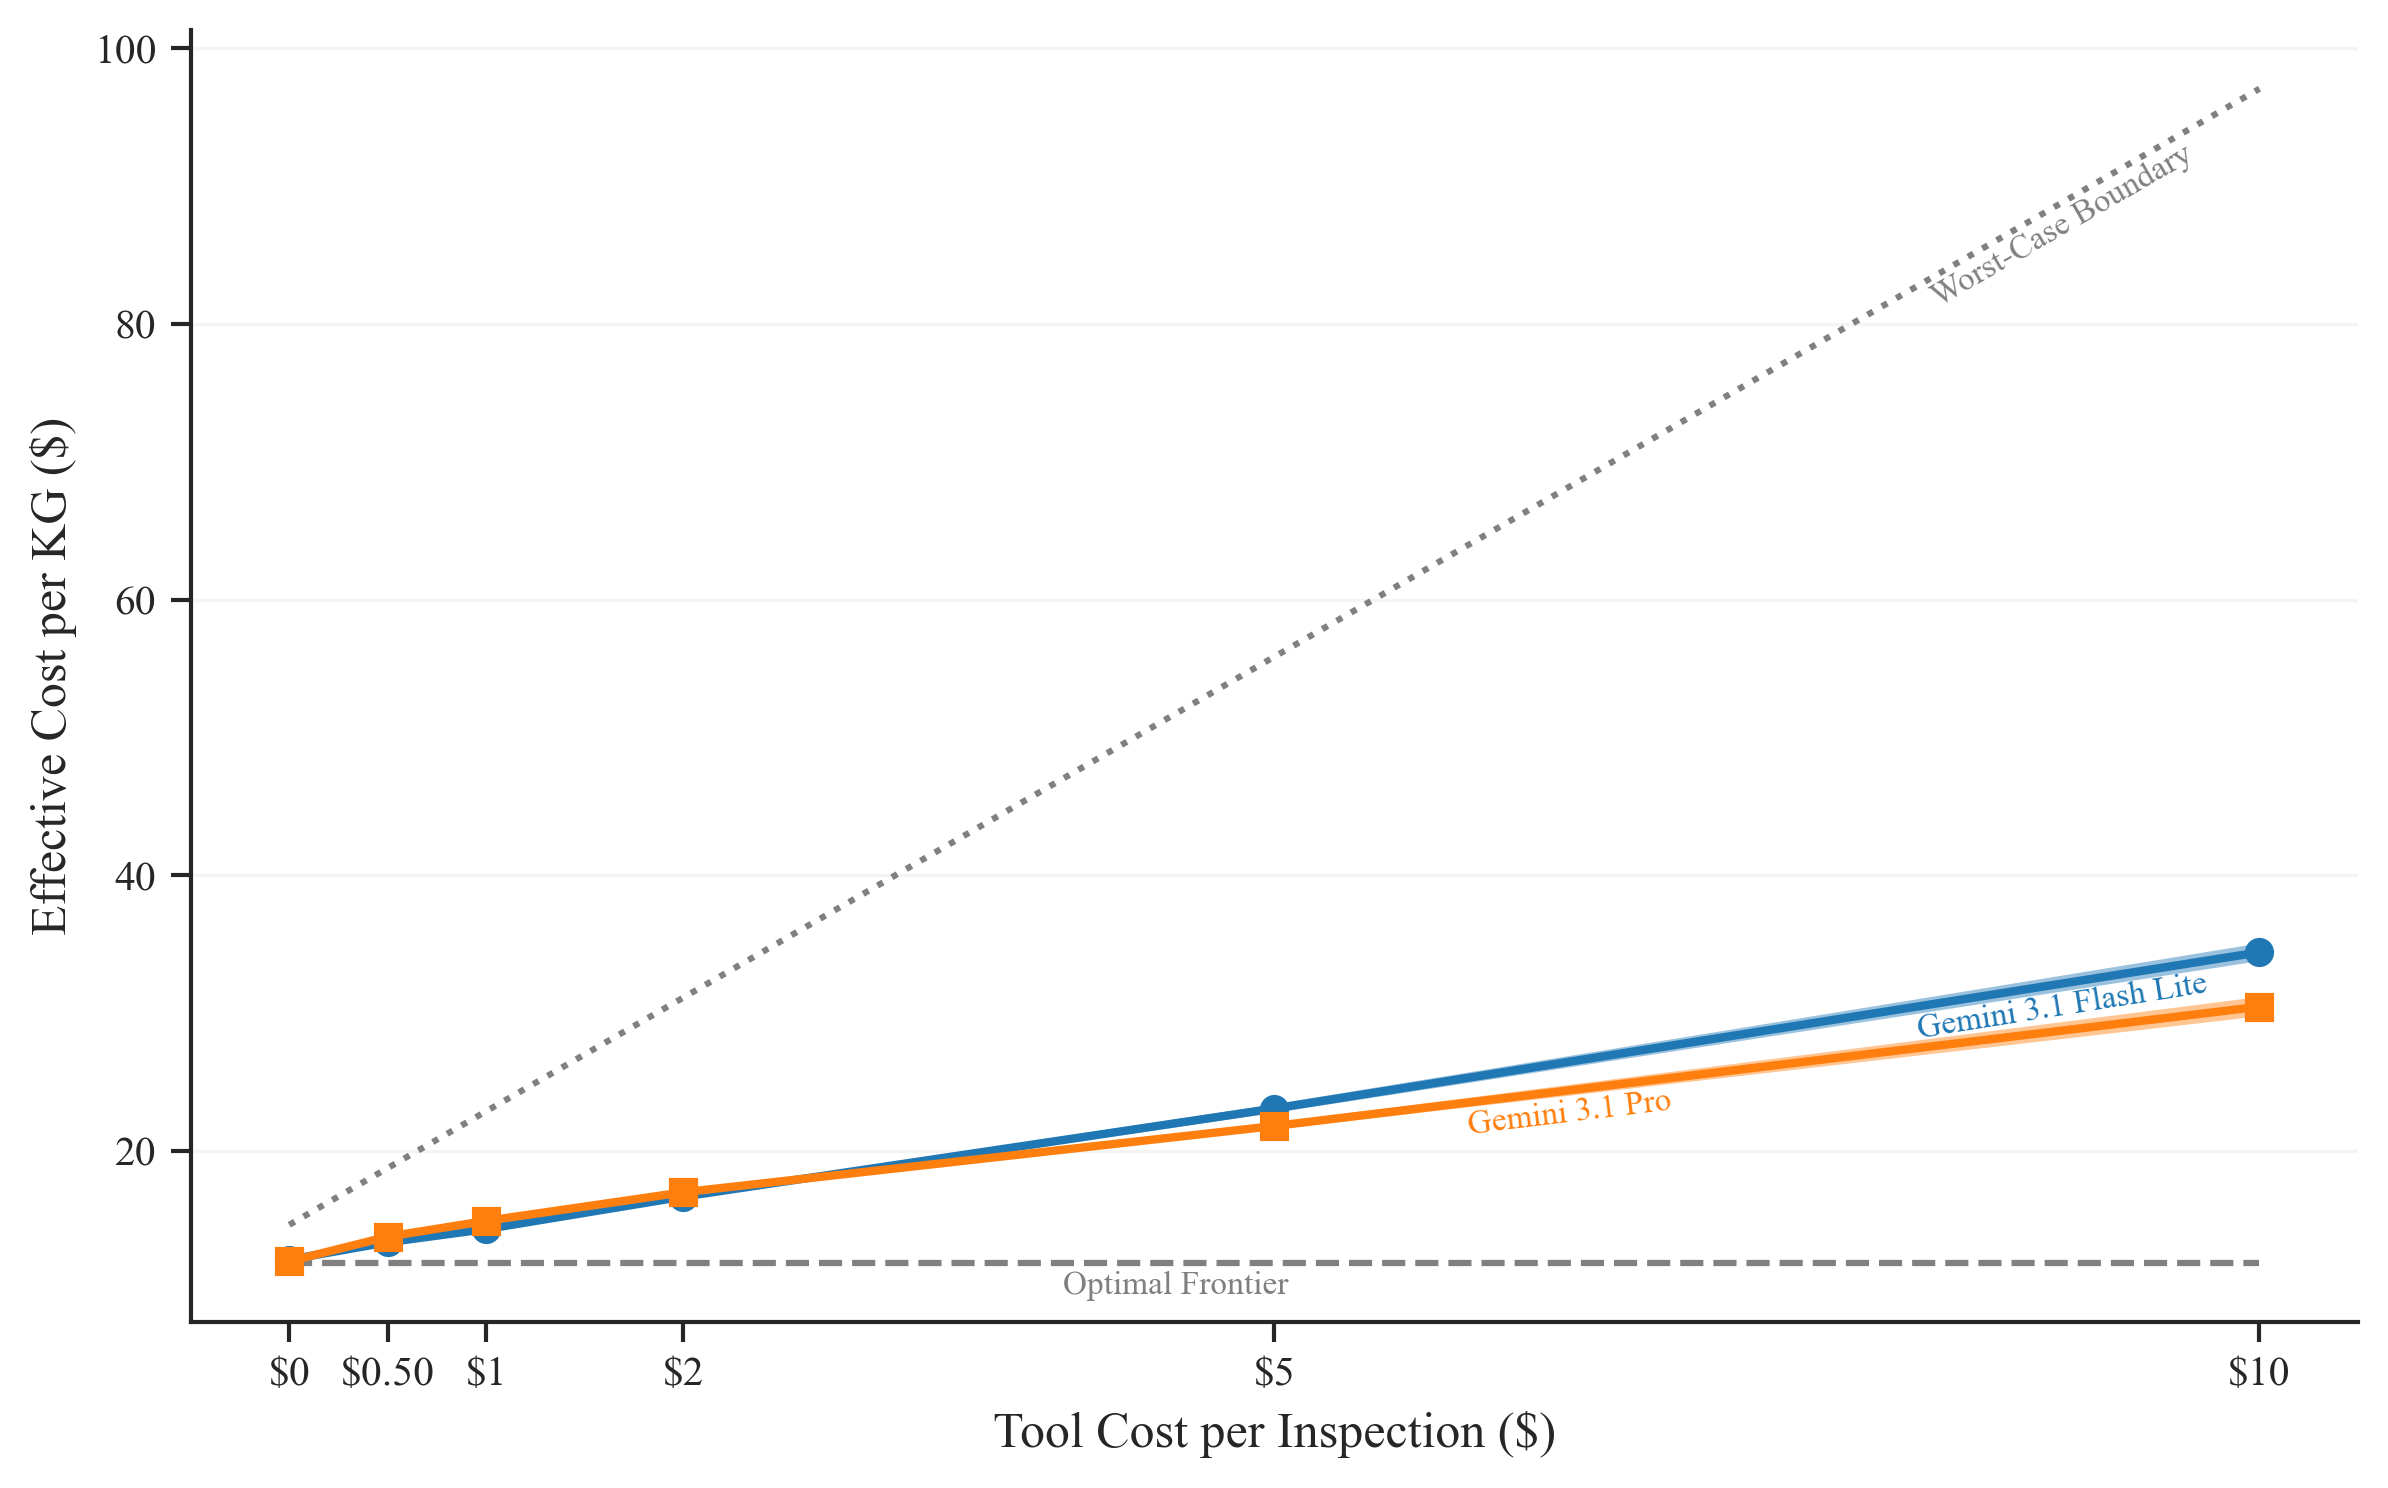

In [153]:
# --- Aggregate data per model with Standard Error ---
agg_df = (
    session_df
    .groupby(['inspect_cell_tool_cost', 'model_name'])
    .agg(
        Effective=('Effective_Cost_Per_KG', 'mean'),
        Effective_SEM=('Effective_Cost_Per_KG', lambda x: x.sem()), # Standard error for shading
        Worst=('Worst_Case_Cost_Per_KG', 'mean'),
        Best=('Best_Case_Cost_Per_KG', 'mean'),
    )
    .reset_index()
)
agg_df['Prop_95CI'] = agg_df['Effective_SEM'] * 1.96

models = agg_df['model_name'].unique()

# --- Plotting configurations ---
# Colors and distinct markers for print/grayscale safety
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green
markers = ['o', 's', '^']

# Increase font sizes for JAMS publication layout
plt.rcParams.update({'font.size': 8, 'axes.labelsize': 12})


fig, ax = plt.subplots(figsize=(8,5))

# --- Plot each model with Confidence Intervals ---
for i, model in enumerate(models):
    mdf = agg_df[agg_df['model_name'] == model].sort_values('inspect_cell_tool_cost')
    x = mdf['inspect_cell_tool_cost']
    y = mdf['Effective']
    y_err = mdf['Prop_95CI']
    
    label_name = model.replace('preview','').replace('-', ' ').title().strip()
    
    # Plot main line
    ax.plot(
        x, y,
        marker=markers[i % len(markers)],
        markersize=6,
        linewidth=2,
        color=colors[i % len(colors)],
        label=label_name
    )
    
    # Add shaded error bands (+/- 1 SEM, or 1.96 for 95% CI)
    ax.fill_between(
        x, y - y_err, y + y_err,
        color=colors[i % len(colors)],
        alpha=0.45,
        edgecolor='none'
    )

# --- Plot Bounds (Subtle, theoretical anchors) ---
ref = agg_df[agg_df['model_name'] == models[0]].sort_values('inspect_cell_tool_cost')
x_vals = ref['inspect_cell_tool_cost'].values

# Worst Case Boundary
ax.plot(x_vals, ref['Worst'].values,
        linewidth=1.5, linestyle=':', color='gray', label='Worst-Case Boundary', zorder=1)

# Optimal Frontier (Best Case)
ax.plot(x_vals, ref['Best'].values,
        linewidth=1.5, linestyle='--', color='gray', label='Optimal Frontier', zorder=1)

# --- Inline labels ---
# Filter lines so we don't accidentally label the fill_between polygons
all_lines = [
    l for l in ax.get_lines()
    if not l.get_label().startswith('_')
    and len(l.get_xdata()) > 1
]

# Adjust xvals depending on where the lines cross / separate best
labelLines(all_lines, xvals=[9.0, 6.5, 9., 4.5, 4.5],yoffsets=-1.7, outline_color=None, outline_width=1, zorder=3)

# --- Formatting ---
ax.set_ylabel("Effective Cost per KG ($)")
ax.set_xlabel("Tool Cost per Inspection ($)")

# Explicitly set X-ticks to the exact constraints tested
ax.set_xticks([0, 0.50, 1.00, 2.00, 5.00, 10.00])
ax.set_xticklabels(['$0', '$0.50', '$1', '$2', '$5', '$10'])

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optional: Add a subtle grid for the y-axis to help read exact monetary values
ax.grid(axis='y', linestyle='-', alpha=0.2)

plt.tight_layout()

print('*Note.* The shaded regions denote the 95% CI.')

*Note.* The shaded regions denote the 95% CI.


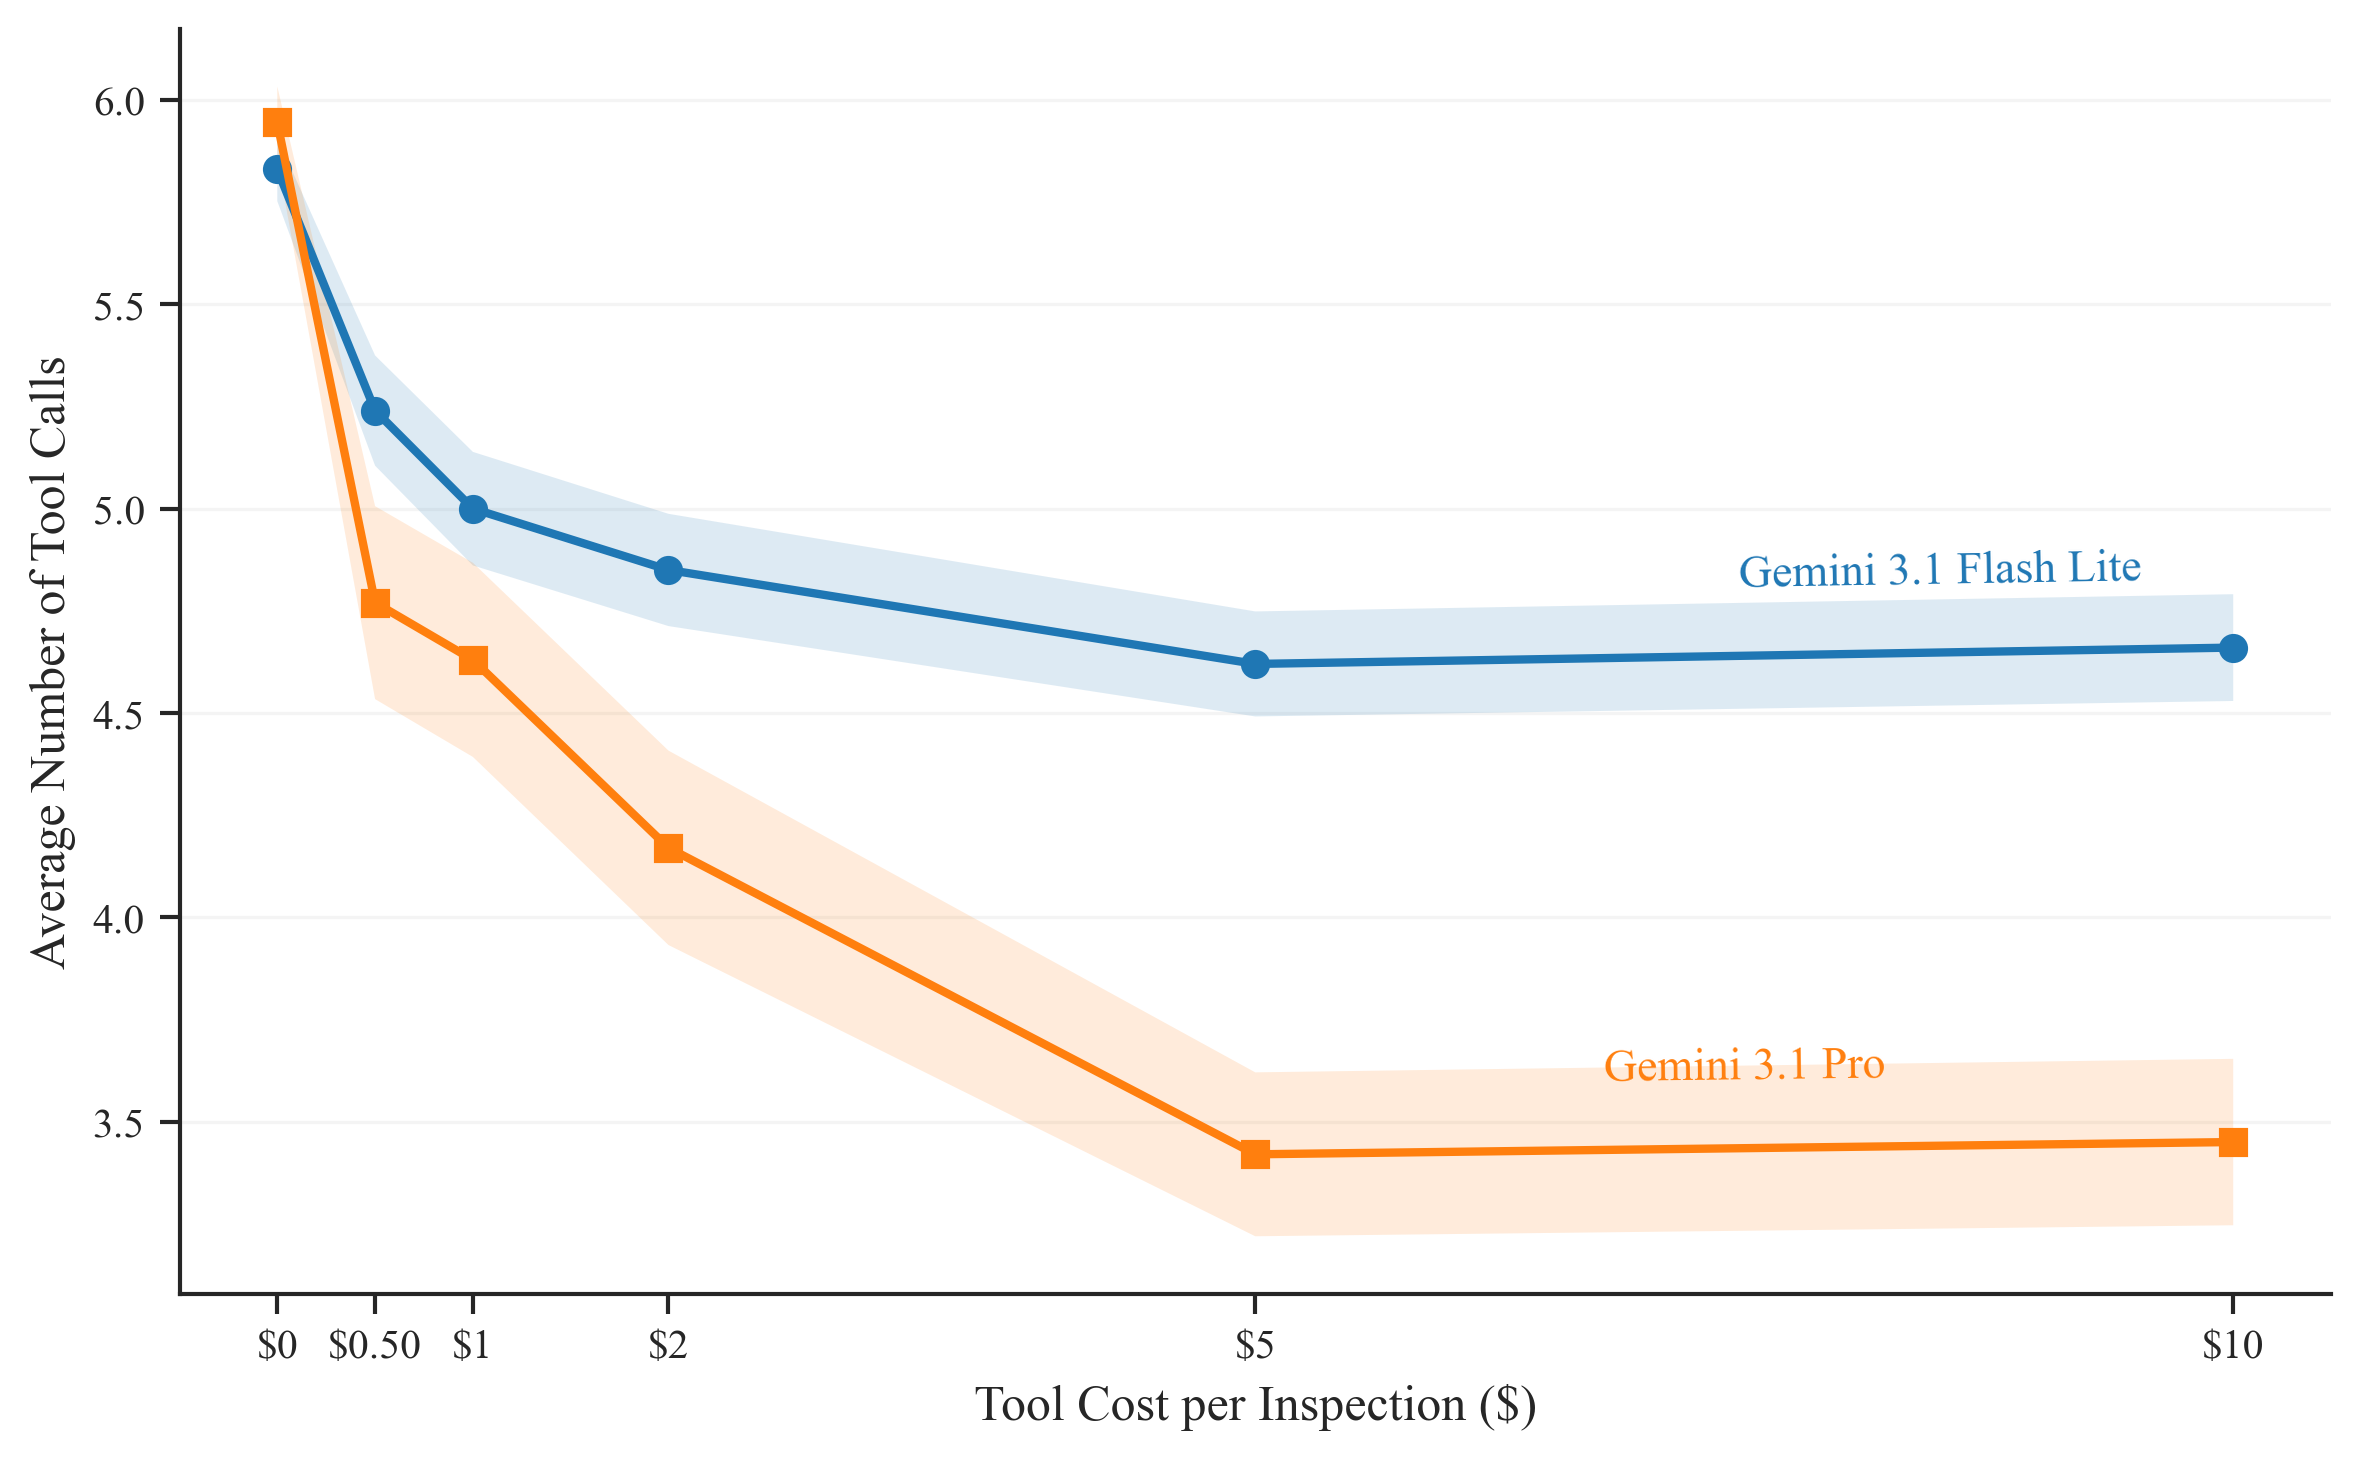

In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from labellines import labelLines

# --- Aggregate data per model for Search Depth ---
agg_calls_df = (
    session_df
    .groupby(['inspect_cell_tool_cost', 'model_name'])
    .agg(
        Calls_Mean=('num_tool_calls', 'mean'),
        Calls_SEM=('num_tool_calls', lambda x: x.sem())
    )
    .reset_index()
)
agg_calls_df['Prop_95CI'] = agg_calls_df['Calls_SEM'] * 1.96

models = agg_calls_df['model_name'].unique()

# --- Plotting configurations ---
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green
markers = ['o', 's', '^']

plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12})
fig, ax = plt.subplots(figsize=(8, 5))

# --- Plot each model with Confidence Intervals ---
for i, model in enumerate(models):
    mdf = agg_calls_df[agg_calls_df['model_name'] == model].sort_values('inspect_cell_tool_cost')
    x = mdf['inspect_cell_tool_cost']
    y = mdf['Calls_Mean']
    y_err = mdf['Prop_95CI']
    
    label_name = model.replace('preview','').replace('-', ' ').title().strip()
    
    # Main line
    ax.plot(
        x, y,
        marker=markers[i % len(markers)],
        markersize=6,
        linewidth=2,
        color=colors[i % len(colors)],
        label=label_name
    )
    
    # Shaded SEM
    ax.fill_between(
        x, y - y_err, y + y_err,
        color=colors[i % len(colors)],
        alpha=0.15,
        edgecolor='none'
    )

# --- Add Theoretical Reference Lines ---
# y=6: Needs Dollars, Cents, and Weight for both A and B to calculate true value
# ax.axhline(y=6, color='gray', linestyle='--', linewidth=1.5, zorder=1, label='Rational Search Baseline (6 cells)')

# y=2: Only checks Dollars for A and B (Heuristic)
# ax.axhline(y=2, color='gray', linestyle=':', linewidth=1.5, zorder=1, label='Heuristic Search Baseline (2 cells)')


# --- Inline labels ---
all_lines = [
    l for l in ax.get_lines()
    if not l.get_label().startswith('_')
    and len(l.get_xdata()) > 1 # Ignore vertical/horizontal lines that span the whole axis for labelLines if needed
]

# Note: We place the inline labels toward the right side (x=8.5 or 9) 
# where the lines typically flatten out, ensuring readability.
labelLines(all_lines, xvals=[8.5, 7.5, 8.0, 4.0, 4.0], yoffsets=.2, outline_color=None, outline_width=3, zorder=3)

# --- Formatting ---
ax.set_ylabel("Average Number of Tool Calls")
ax.set_xlabel("Tool Cost per Inspection ($)")

# Explicitly set X-ticks to the exact constraints tested
ax.set_xticks([0, 0.50, 1.00, 2.00, 5.00, 10.00])
ax.set_xticklabels(['$0', '$0.50', '$1', '$2', '$5', '$10'])

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', linestyle='-', alpha=0.2)

plt.tight_layout()

print('*Note.* The shaded regions denote the 95% CI.')

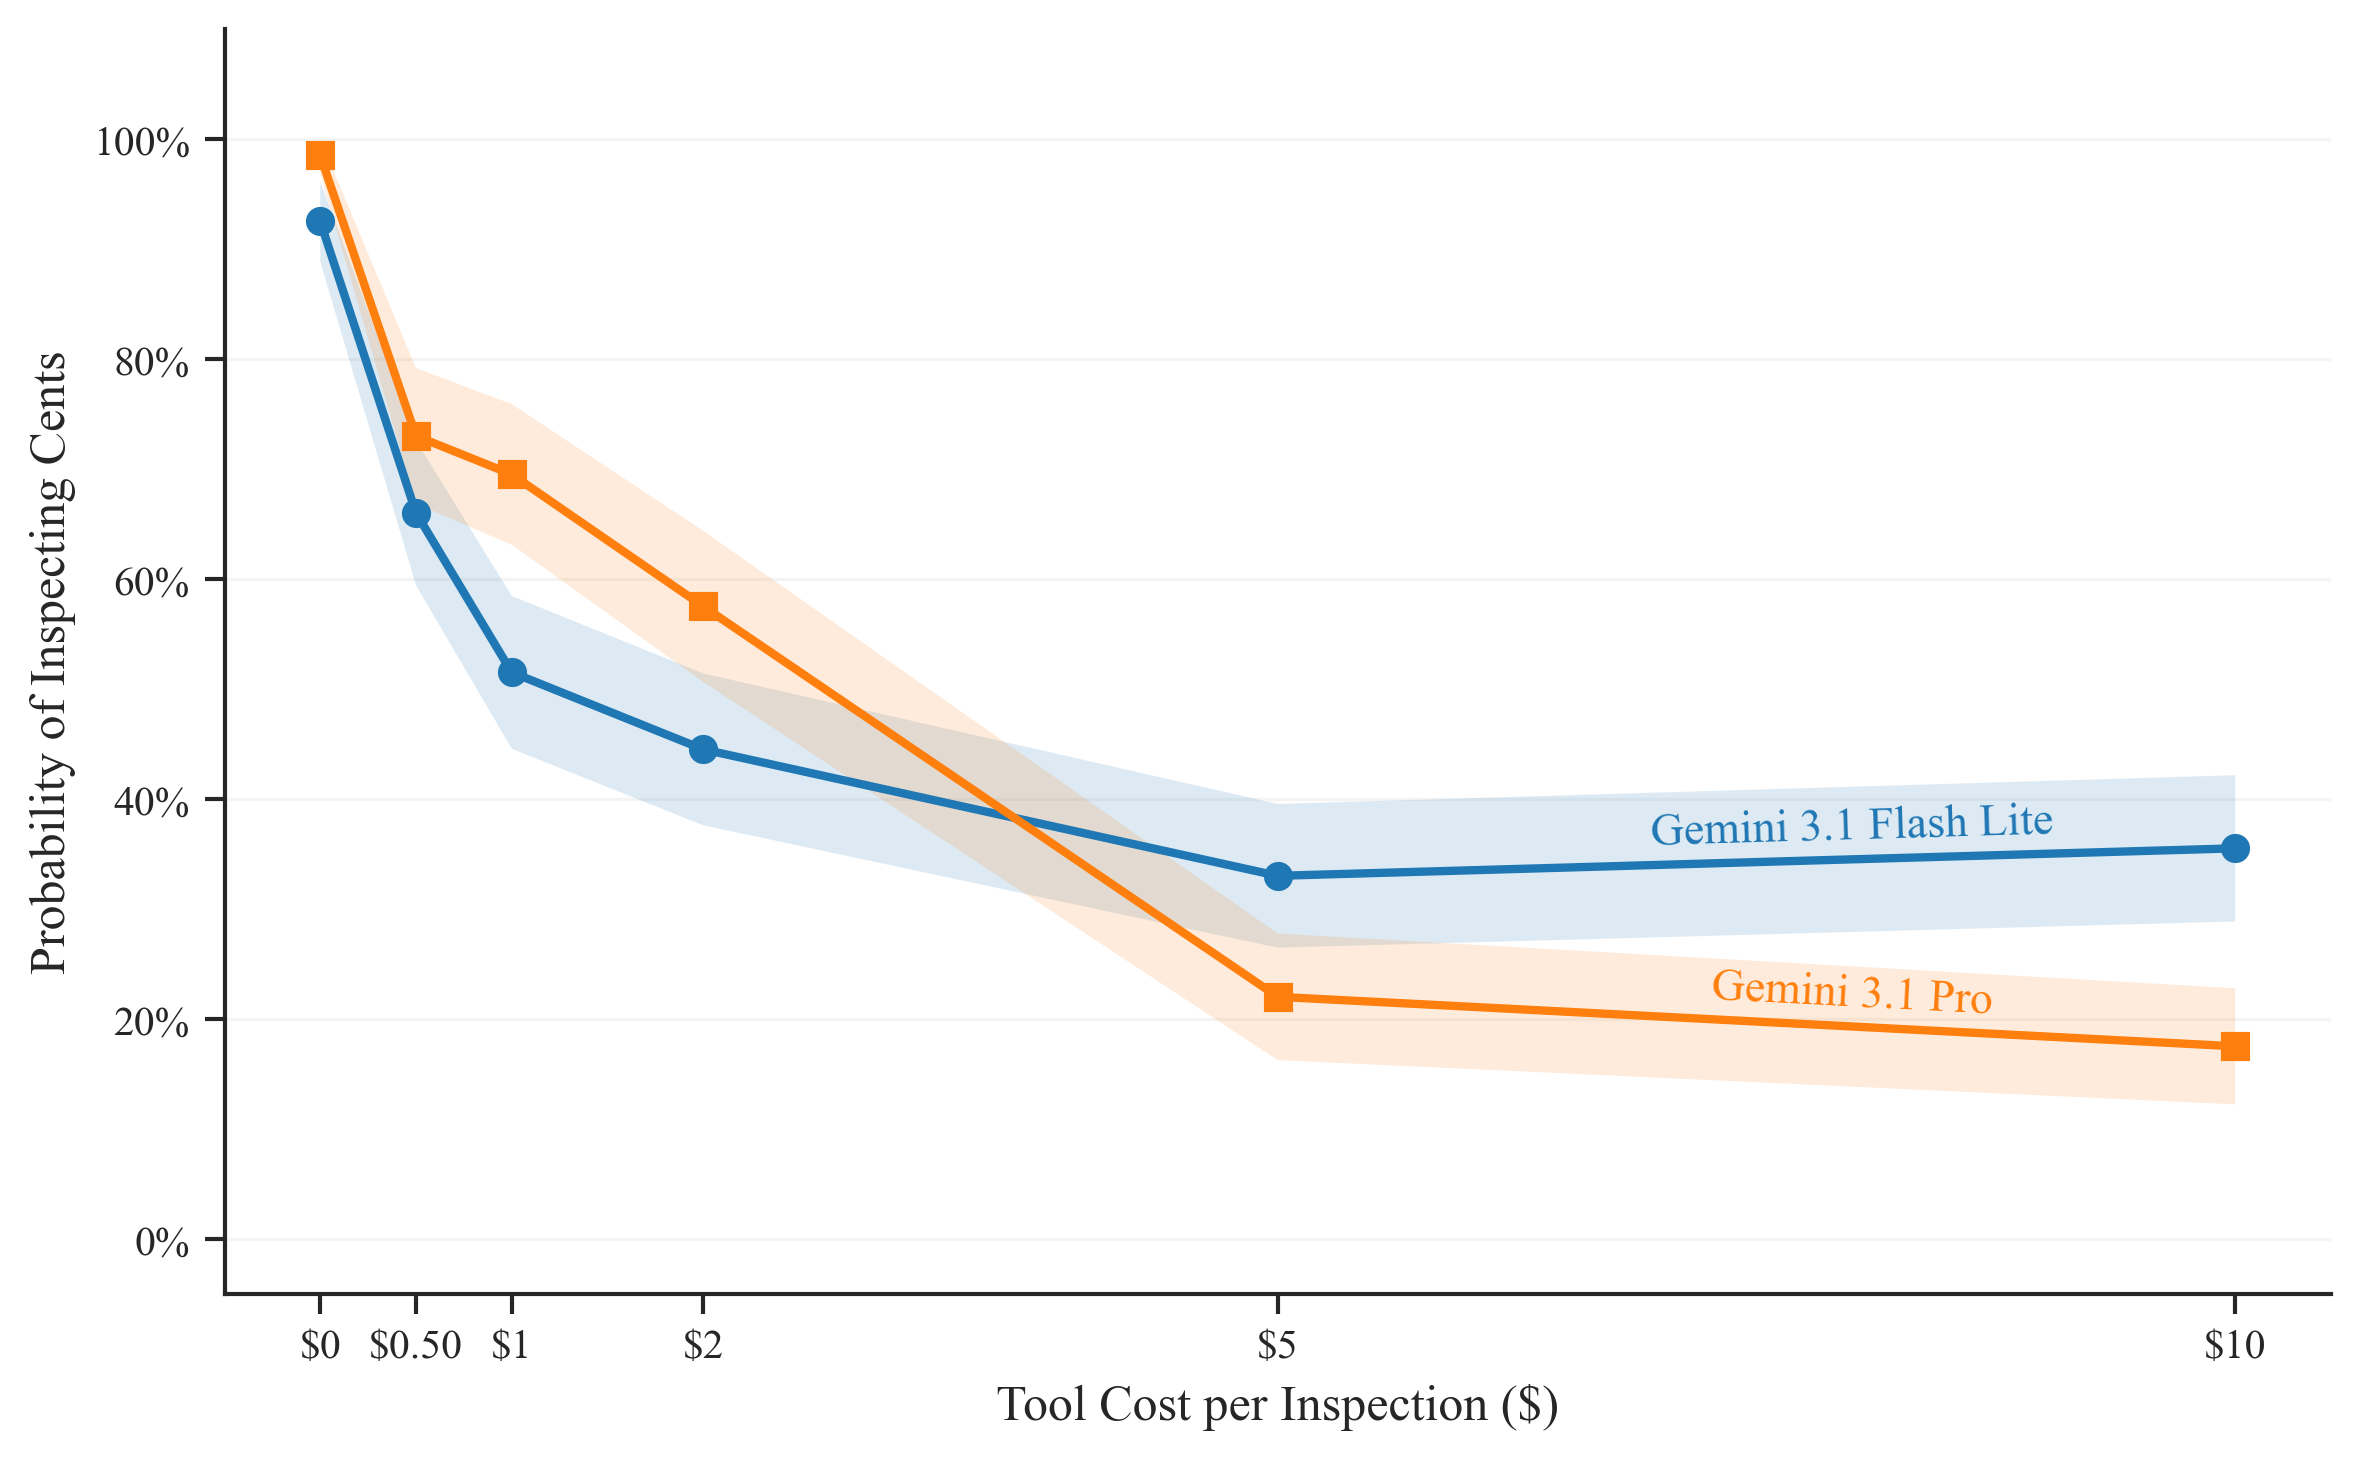

*Note.* The shaded regions denote the 95% CI.


In [155]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from labellines import labelLines

# --- 1. Create the dependent variable (if not already done) ---
# Example: session_df['checked_cents'] = session_df['tool_call_log'].str.contains('price_cents')
# (Ensure 'checked_cents' is binary: 1 for checked, 0 for ignored)

# --- 2. Aggregate data per model with Standard Error ---
agg_df = (
    session_df
    .groupby(['inspect_cell_tool_cost', 'model_name'])
    .agg(
        Prop_Checked=('checked_cents', 'mean'), # Returns proportion (0 to 1)
        Prop_SEM=('checked_cents', lambda x: x.sem()) # Standard error for shading
    )
    .reset_index()
)
# Calculate the 95% CI margin of error
agg_df['Prop_95CI'] = agg_df['Prop_SEM'] * 1.96

models = agg_df['model_name'].unique()

# --- 3. Plotting configurations ---
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green
markers = ['o', 's', '^']

plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12})

fig, ax = plt.subplots(figsize=(8, 5))

# --- 4. Plot each model ---
for i, model in enumerate(models):
    mdf = agg_df[agg_df['model_name'] == model].sort_values('inspect_cell_tool_cost')
    x = mdf['inspect_cell_tool_cost']
    y = mdf['Prop_Checked']
    y_err = mdf['Prop_95CI']
    
    label_name = model.replace('preview','').replace('-', ' ').title().strip()
    
    # Plot main line
    ax.plot(
        x, y,
        marker=markers[i % len(markers)],
        markersize=6,
        linewidth=2,
        color=colors[i % len(colors)],
        label=label_name
    )
    
    # Add shaded error bands (+/- 1 SEM)
    # Use np.clip to ensure lower bound doesn't dip below 0% mathematically
    ax.fill_between(
        x, np.clip(y - y_err, 0, 1), np.clip(y + y_err, 0, 1),
        color=colors[i % len(colors)],
        alpha=0.15,
        edgecolor='none'
    )

# --- 5. Add Theoretical Baseline ---
# To make a rational decision, the model *must* check the cents. 
# Therefore, rational behavior = 100% (1.0).
# ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='Rational Search Baseline', zorder=1)

# --- 6. Inline labels ---
all_lines = [
    l for l in ax.get_lines()
    if not l.get_label().startswith('_')
]

# Adjust xvals depending on where the lines cross / separate best.
# Since probability usually drops sharply as tool costs rise, placing labels around $1-$5 usually works well here.
labelLines(all_lines, xvals=8, yoffsets=.03, outline_color=None, outline_width=3, zorder=3)

# --- 7. Formatting ---
ax.set_ylabel("Probability of Inspecting Cents")
ax.set_xlabel("Tool Cost per Inspection ($)")

# Format Y-axis as percentages (0% to 100%)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(-0.05, 1.1) # Give a little padding above 100% and below 0%

# Explicitly set X-ticks to the exact constraints tested
ax.set_xticks([0, 0.50, 1.00, 2.00, 5.00, 10.00])
ax.set_xticklabels(['$0', '$0.50', '$1', '$2', '$5', '$10'])

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Optional: Add subtle horizontal grid lines to easily read 20%, 40%, etc.
ax.grid(axis='y', linestyle='-', alpha=0.2)

plt.tight_layout()
plt.show()
print('*Note.* The shaded regions denote the 95% CI.')

In [156]:
import pandas as pd
import numpy as np

# Assuming your step-level dataframe is called `df` and has a `session_name` column
# 1. Create binary flags for the transitions we care about
df['is_alternative'] = (df['transition'] == 'alternative').astype(int)
df['is_attribute'] = (df['transition'] == 'attribute').astype(int)

# 2. Group by session to count the transitions
session_strategy = df.groupby(['session_name', 'model_name', 'inspect_cell_tool_cost']).agg(
    alt_count=('is_alternative', 'sum'),
    attr_count=('is_attribute', 'sum')
).reset_index()

# 3. Calculate total valid transitions
session_strategy['total_relevant'] = session_strategy['alt_count'] + session_strategy['attr_count']

# Filter out sessions with 0 relevant transitions 
# (e.g., if tool cost is $10 and they only clicked 1 cell and gave up)
valid_sessions = session_strategy[session_strategy['total_relevant'] > 0].copy()

# 4. Compute Session-Level Metrics
valid_sessions['pct_alternative'] = valid_sessions['alt_count'] / valid_sessions['total_relevant']
valid_sessions['pct_attribute'] = valid_sessions['attr_count'] / valid_sessions['total_relevant']

# Compute the Payne Index: (Alt - Attr) / (Alt + Attr)
valid_sessions['payne_index'] = (valid_sessions['alt_count'] - valid_sessions['attr_count']) / valid_sessions['total_relevant']

# 5. Aggregate by Tool Cost and Model for the final table
strategy_summary = valid_sessions.groupby(['inspect_cell_tool_cost', 'model_name']).agg(
    Mean_Pct_Alt=('pct_alternative', 'mean'),
    Mean_Payne_Index=('payne_index', 'mean'),
    Valid_Sessions=('session_name', 'count') # Good to know how many actually searched vs guessed
).reset_index()

# 6. Pivot into a clean publication table (Focusing on Payne Index)
# Multiplying by 100 for Pct, and rounding
strategy_summary['Mean_Pct_Alt'] = (strategy_summary['Mean_Pct_Alt'] * 100).round(1)
strategy_summary['Mean_Payne_Index'] = strategy_summary['Mean_Payne_Index'].round(2)

# Pivot table for Alternative Percentage
table_pct_alt = strategy_summary.pivot(
    index='inspect_cell_tool_cost', 
    columns='model_name', 
    values='Mean_Pct_Alt'
)

# Pivot table for Payne Index
table_payne = strategy_summary.pivot(
    index='inspect_cell_tool_cost', 
    columns='model_name', 
    values='Mean_Payne_Index'
)

print("--- Percentage of Alternative-Based Transitions (%) ---")
display(table_pct_alt)
print("\n--- Payne Index (Search Strategy: -1 to +1) ---")
display(table_payne)


--- Percentage of Alternative-Based Transitions (%) ---


model_name,gemini-3.1-flash-lite-preview,gemini-3.1-pro-preview
inspect_cell_tool_cost,,
0.0,55.7,50.8
0.5,37.7,22.4
1.0,29.9,24.5
2.0,38.6,20.2
5.0,33.9,14.2
10.0,35.4,15.6



--- Payne Index (Search Strategy: -1 to +1) ---


model_name,gemini-3.1-flash-lite-preview,gemini-3.1-pro-preview
inspect_cell_tool_cost,,
0.0,0.11,0.02
0.5,-0.25,-0.55
1.0,-0.40,-0.51
2.0,-0.23,-0.60
5.0,-0.32,-0.72
10.0,-0.29,-0.69


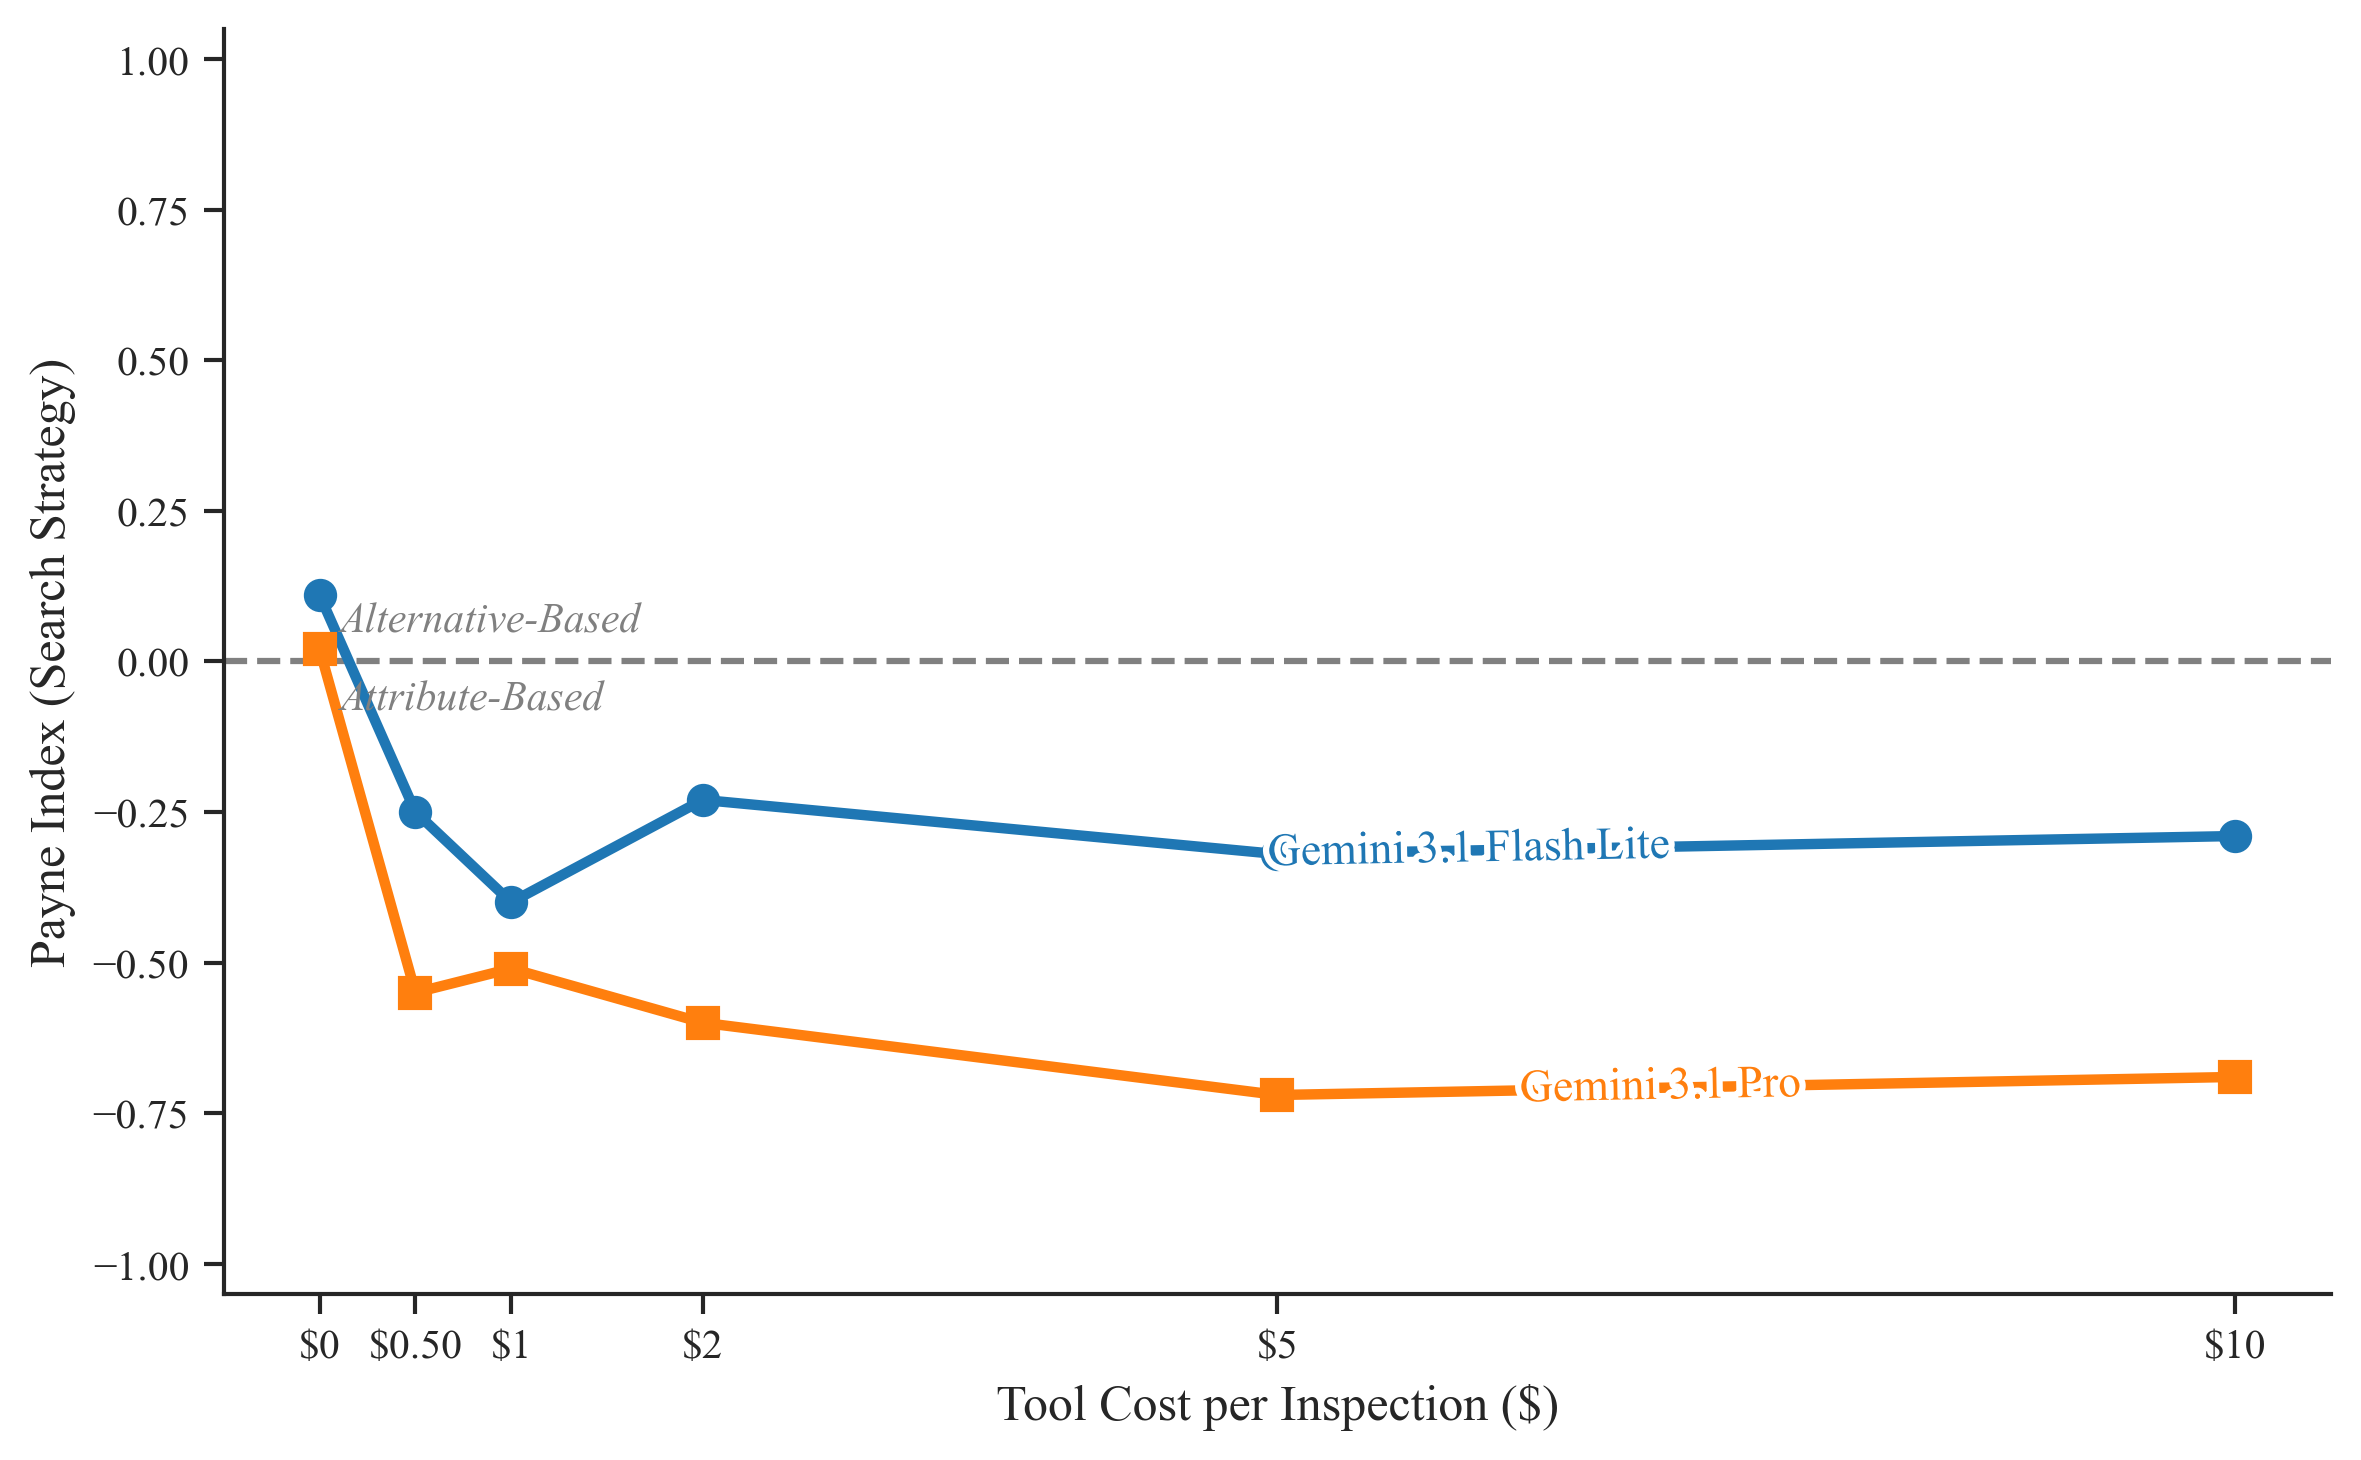

In [157]:
import matplotlib.pyplot as plt
from labellines import labelLines

# --- Plotting configurations ---
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green
markers = ['o', 's', '^']

plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12})
fig, ax = plt.subplots(figsize=(8, 5))

# --- Add the theoretical boundary line (y=0) ---
# This is critical for the Payne Index: it separates Rational from Heuristic
ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, zorder=1)
ax.text(0.1, 0.05, 'Alternative-Based', color='gray', fontsize=10, fontstyle='italic')
ax.text(0.1, -0.08, 'Attribute-Based', color='gray', fontsize=10, fontstyle='italic')

# --- Plot each model's Payne Index ---
models = strategy_summary['model_name'].unique()

for i, model in enumerate(models):
    mdf = strategy_summary[strategy_summary['model_name'] == model].sort_values('inspect_cell_tool_cost')
    
    # Filter out NaNs if a model completely stopped searching at high costs
    mdf = mdf.dropna(subset=['Mean_Payne_Index'])
    
    label_name = model.replace('preview','').replace('-', ' ').title().strip()
    
    ax.plot(
        mdf['inspect_cell_tool_cost'], 
        mdf['Mean_Payne_Index'],
        marker=markers[i % len(markers)],
        markersize=7,
        linewidth=2.5,
        color=colors[i % len(colors)],
        label=label_name,
        zorder=2
    )

# --- Inline labels (No Legend) ---
all_lines = [
    l for l in ax.get_lines()
    if not l.get_label().startswith('_')
    and len(l.get_xdata()) > 1
]
# Adjust xvals to place the labels nicely on the right side of the plot
labelLines(all_lines, xvals=[6, 7, 8], outline_color='white', outline_width=3, zorder=3)

# --- Formatting ---
ax.set_ylabel("Payne Index (Search Strategy)")
ax.set_xlabel("Tool Cost per Inspection ($)")

# Fix Y-axis to standard Payne Index bounds (-1 to 1) 
# (You can adjust to -1 to 0.5 if no model ever reaches +1)
ax.set_ylim(-1.05, 1.05) 

# Explicit X-ticks
ax.set_xticks([0, 0.50, 1.00, 2.00, 5.00, 10.00])
ax.set_xticklabels(['$0', '$0.50', '$1', '$2', '$5', '$10'])

# Clean JAMS aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

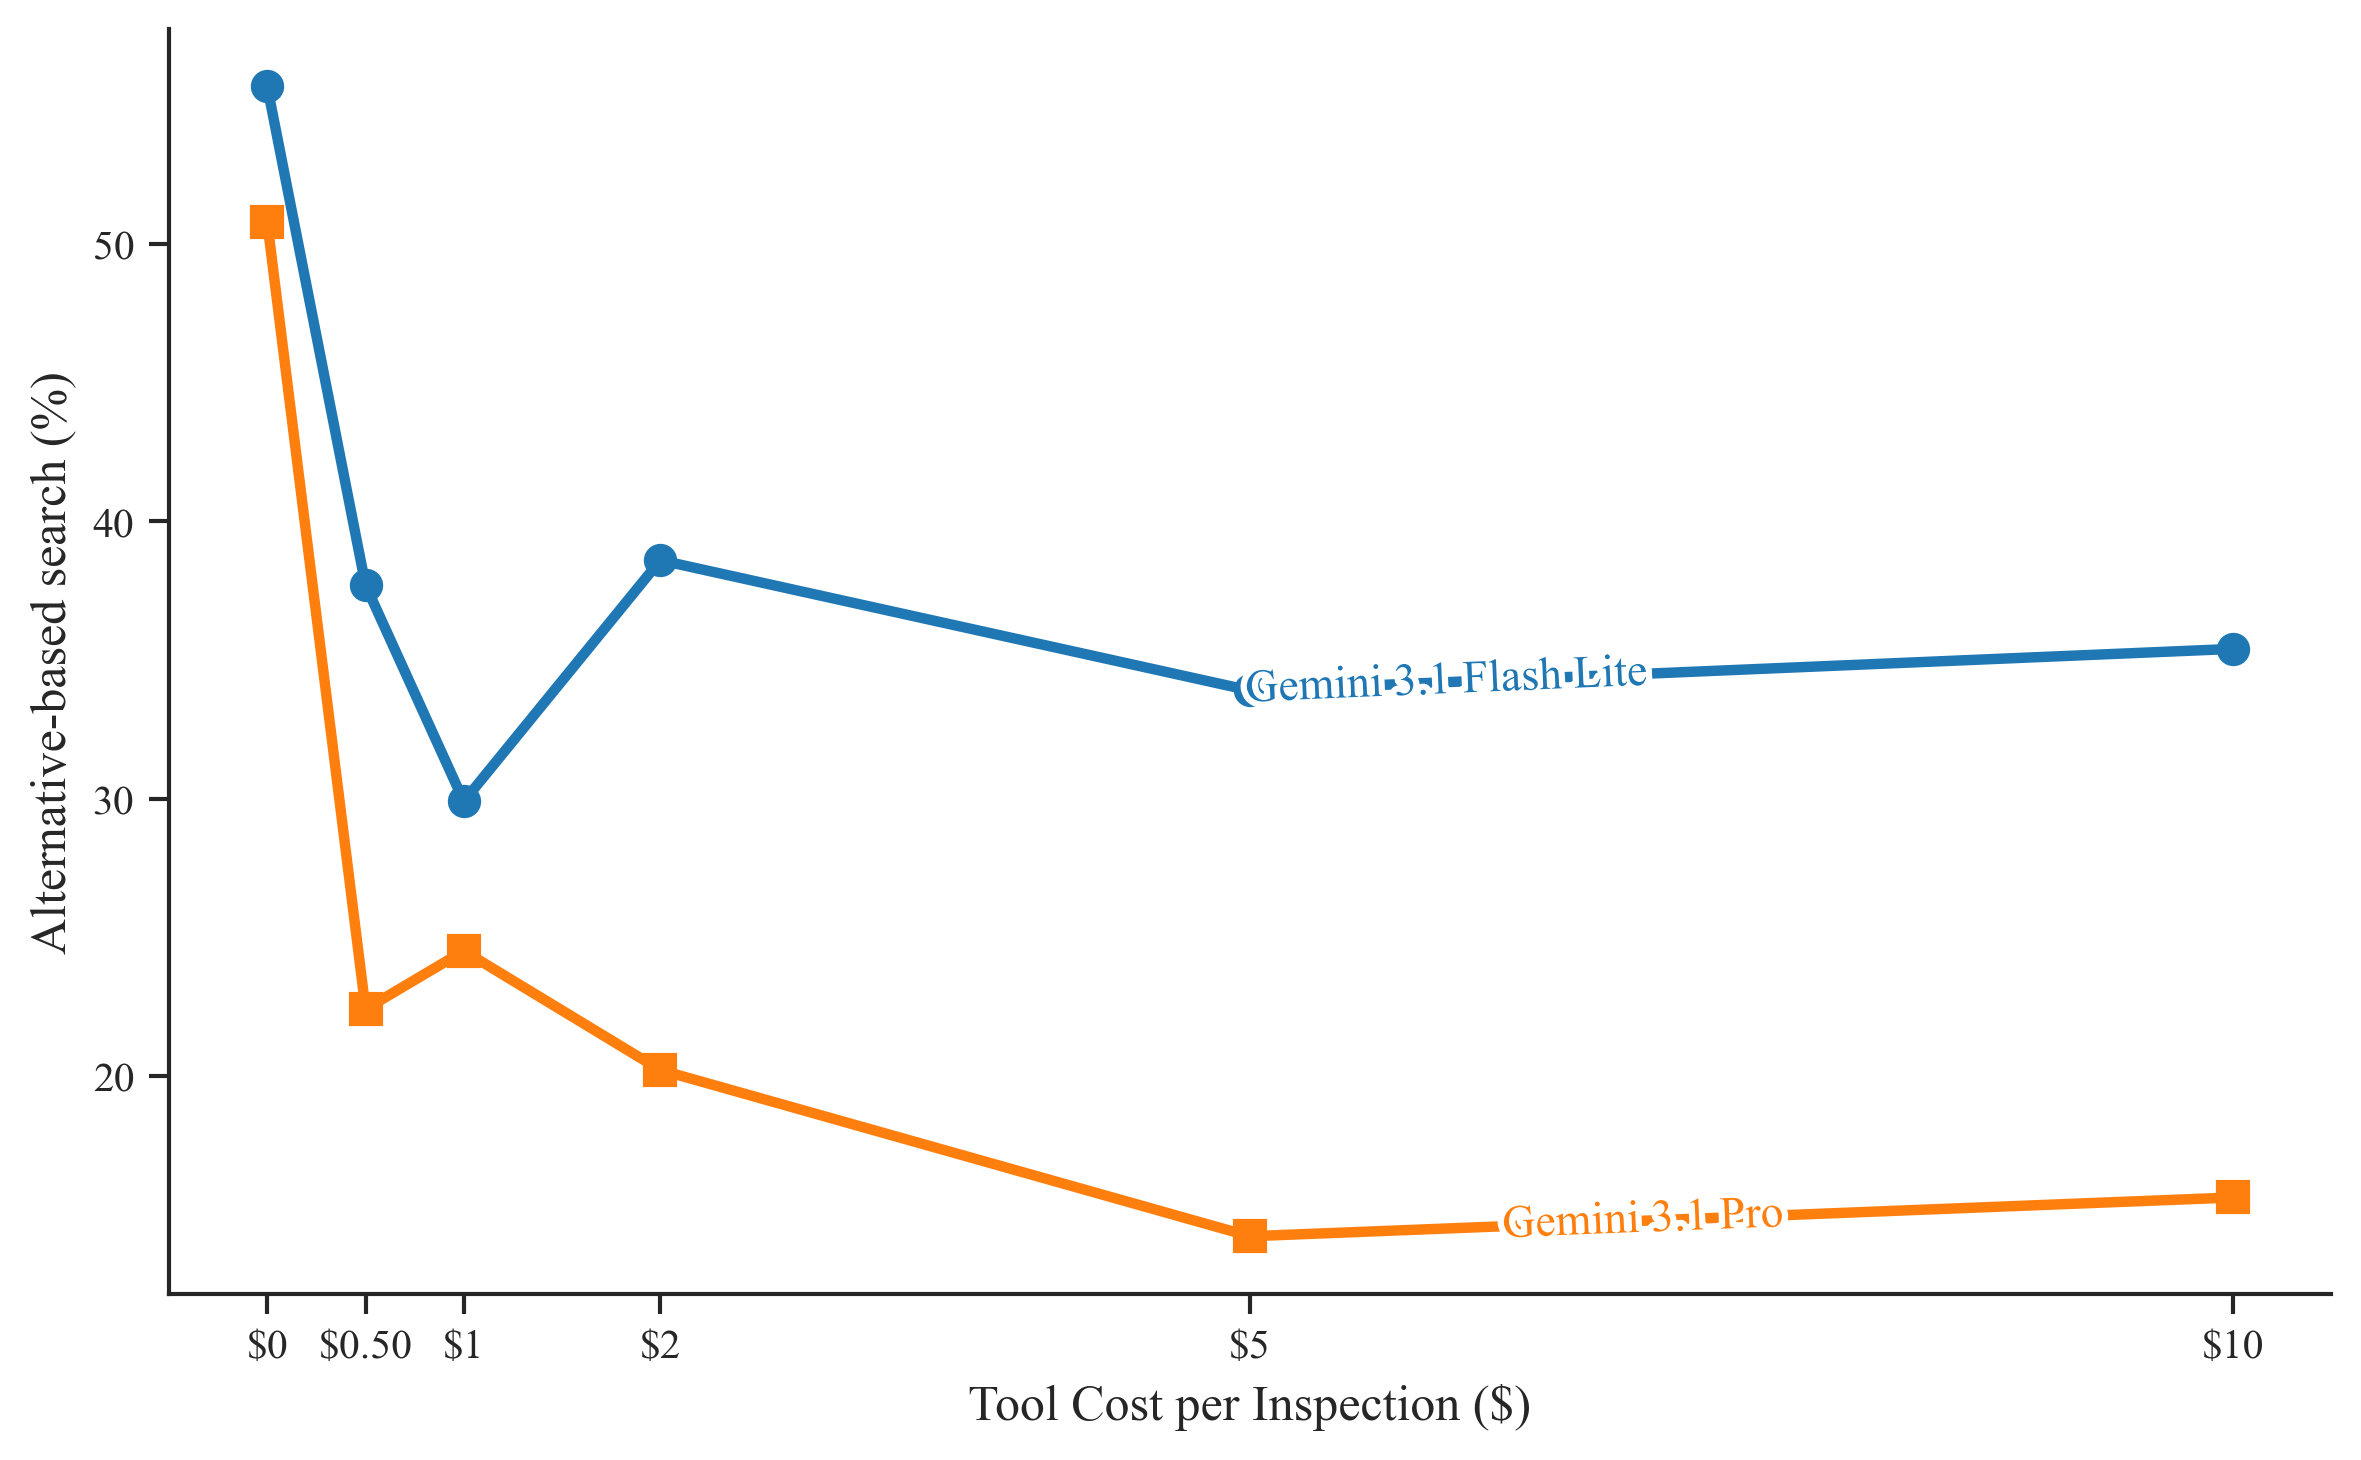

In [158]:
import matplotlib.pyplot as plt
from labellines import labelLines

# --- Plotting configurations ---
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green
markers = ['o', 's', '^']

plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12})
fig, ax = plt.subplots(figsize=(8, 5))


# --- Plot each model's Payne Index ---
models = strategy_summary['model_name'].unique()

for i, model in enumerate(models):
    mdf = strategy_summary[strategy_summary['model_name'] == model].sort_values('inspect_cell_tool_cost')
    
    # Filter out NaNs if a model completely stopped searching at high costs
    mdf = mdf.dropna(subset=['Mean_Pct_Alt'])
    
    label_name = model.replace('preview','').replace('-', ' ').title().strip()
    
    ax.plot(
        mdf['inspect_cell_tool_cost'], 
        mdf['Mean_Pct_Alt'],
        marker=markers[i % len(markers)],
        markersize=7,
        linewidth=2.5,
        color=colors[i % len(colors)],
        label=label_name,
        zorder=2
    )

# --- Inline labels (No Legend) ---
all_lines = [
    l for l in ax.get_lines()
    if not l.get_label().startswith('_')
    and len(l.get_xdata()) > 1
]
# Adjust xvals to place the labels nicely on the right side of the plot
labelLines(all_lines, xvals=[6, 7, 8], outline_color='white', outline_width=3, zorder=3)

# --- Formatting ---
ax.set_ylabel("Alternative-based search (%)")
ax.set_xlabel("Tool Cost per Inspection ($)")

# Fix Y-axis to standard Payne Index bounds (-1 to 1) 
# (You can adjust to -1 to 0.5 if no model ever reaches +1)
# ax.set_ylim(-1.05, 1.05) 

# Explicit X-ticks
ax.set_xticks([0, 0.50, 1.00, 2.00, 5.00, 10.00])
ax.set_xticklabels(['$0', '$0.50', '$1', '$2', '$5', '$10'])

# Clean JAMS aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

In [73]:
# session_df['Effective_Cost_Per_Gram'].describe()

# session_df['prompt_type_cat'] = session_df['prompt_type'].astype('category')
# session_df['model_name_cat'] = session_df['model_name'].astype('category')

# # Set the reference levels as requested
# session_df['prompt_type_cat'] = session_df['prompt_type_cat'].cat.reorder_categories(['deal', 'value_function'], ordered=False)
# # Ensure your exact model string matches the one in your dataframe
# # session_df['model_name_cat'] = session_df['model_name_cat'].cat.reorder_categories(['gemini-3.1-pro-preview', 'gemini-3-flash-preview','gemini-3.1-flash-lite-preview'], ordered=False) 
# session_df['model_name_cat'] = session_df['model_name_cat'].cat.reorder_categories([
#     'gemini-3.1-flash-lite-preview',
#     'gemini-3-flash-preview',
#     'gemini-3.1-pro-preview', 
# ], ordered=False) 


# cost_model = smf.ols(
#     "Effective_Cost_Per_KG ~ C(prompt_type_cat) * C(model_name_cat) + C(prompt_type_cat) * inspect_cell_tool_cost", 
#     data=session_df
# ).fit()

# print(cost_model.summary())

### Mediation analysis

Text(0, 0.5, 'Number of Tool Calls')

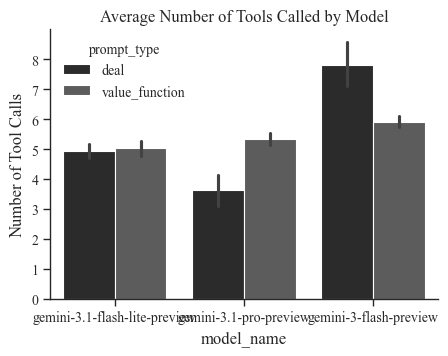

In [69]:
sns.barplot(
    data=session_df, 
    x='model_name', 
    y='num_tool_calls', 
    hue='prompt_type'
)
plt.title("Average Number of Tools Called by Model")
plt.ylabel("Number of Tool Calls")


Text(0, 0.5, '% of Time Price Cents Was Checked')

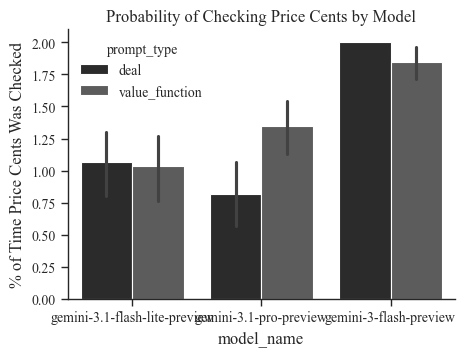

In [71]:
# Assuming 'checked_price_cents' is a boolean (True/False) or 0/1
sns.barplot(
    data=session_df, 
    x='model_name', 
    y='num_check_cents', # replace with your actual column name
    hue='prompt_type'
)
plt.title("Probability of Checking Price Cents by Model")
plt.ylabel("% of Time Price Cents Was Checked")


In [73]:
# Regression to explain the MECHANISM
mechanism_model = smf.ols(
    "Effective_Cost_Per_KG ~ C(prompt_type_cat) * C(model_name_cat) + num_tool_calls + num_check_cents", 
    data=session_df
).fit()

print(mechanism_model.summary())


                              OLS Regression Results                             
Dep. Variable:     Effective_Cost_Per_KG   R-squared:                       0.107
Model:                               OLS   Adj. R-squared:                  0.089
Method:                    Least Squares   F-statistic:                     5.970
Date:                   Mon, 20 Apr 2026   Prob (F-statistic):           1.41e-06
Time:                           11:13:48   Log-Likelihood:                -1233.6
No. Observations:                    355   AIC:                             2483.
Df Residuals:                        347   BIC:                             2514.
Df Model:                              7                                         
Covariance Type:               nonrobust                                         
                                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

Text(45.7361689814815, 0.5, 'Number of Tools Called')

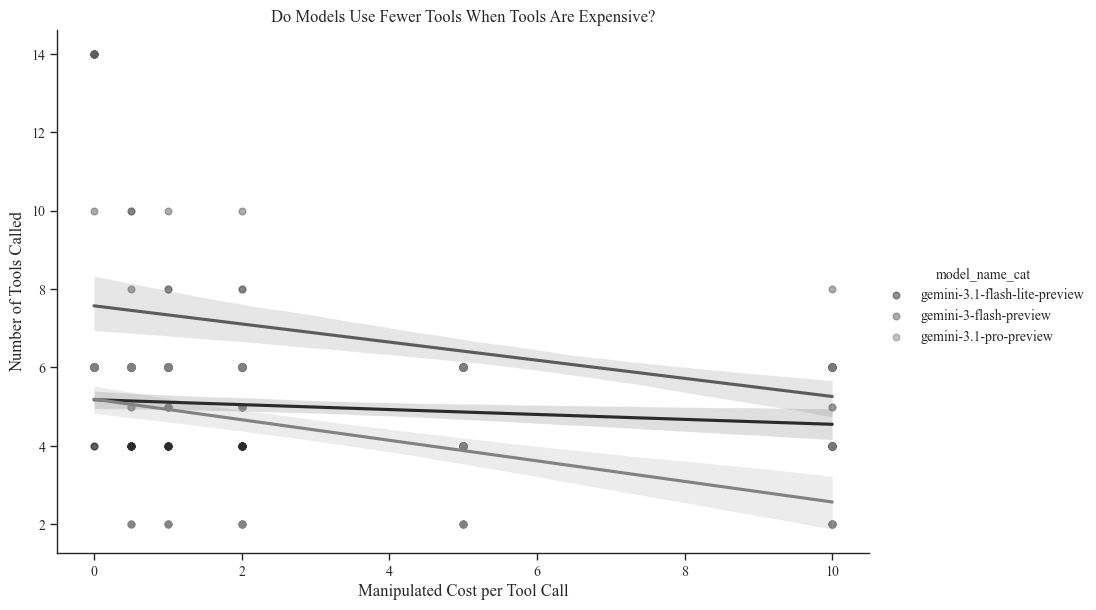

In [74]:
sns.lmplot(
    data=session_df,
    x='inspect_cell_tool_cost',
    y='num_tool_calls',
    hue='model_name_cat',
    height=6,
    aspect=1.5,
    scatter_kws={'alpha': 0.5}
)
plt.title("Do Models Use Fewer Tools When Tools Are Expensive?")
plt.xlabel("Manipulated Cost per Tool Call")
plt.ylabel("Number of Tools Called")

In [75]:
# We are now predicting BEHAVIOR, not total cost.
behavior_model = smf.ols(
    "num_tool_calls ~ C(model_name_cat) * inspect_cell_tool_cost", 
    data=session_df
).fit()

print(behavior_model.summary())


                            OLS Regression Results                            
Dep. Variable:         num_tool_calls   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     39.10
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           7.51e-32
Time:                        11:21:22   Log-Likelihood:                -682.43
No. Observations:                 355   AIC:                             1377.
Df Residuals:                     349   BIC:                             1400.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

### Moderated mediation

In [106]:
# Assuming checked_price_cents is a 0/1 integer or boolean
heuristic_model = smf.ols(
    "num_check_cents ~ C(model_name_cat) * inspect_cell_tool_cost", 
    data=session_df
).fit()

print(heuristic_model.summary())


                            OLS Regression Results                            
Dep. Variable:        num_check_cents   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     32.72
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           2.37e-27
Time:                        11:47:36   Log-Likelihood:                -402.62
No. Observations:                 355   AIC:                             817.2
Df Residuals:                     349   BIC:                             840.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In [109]:
terms = 'Effective_Cost_Per_KG ~ '
terms += 'C(model_name_cat) '
terms += '+ inspect_cell_tool_cost * num_tool_calls '
terms += '+ inspect_cell_tool_cost * C(checked_cents) '
# terms += '+ inspect_cell_tool_cost * num_check_cents'

rationality_model = smf.ols(
    terms, 
    data=session_df
).fit()

print(rationality_model.summary())


                              OLS Regression Results                             
Dep. Variable:     Effective_Cost_Per_KG   R-squared:                       0.992
Model:                               OLS   Adj. R-squared:                  0.992
Method:                    Least Squares   F-statistic:                     6418.
Date:                   Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                           11:48:43   Log-Likelihood:                -389.21
No. Observations:                    355   AIC:                             794.4
Df Residuals:                        347   BIC:                             825.4
Df Model:                              7                                         
Covariance Type:               nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [112]:
full_mediation_model = smf.ols(
    "Effective_Cost_Per_KG ~ C(model_name_cat) * inspect_cell_tool_cost + num_tool_calls + C(checked_cents)", 
    data=session_df
).fit()

print(full_mediation_model.summary())


                              OLS Regression Results                             
Dep. Variable:     Effective_Cost_Per_KG   R-squared:                       0.953
Model:                               OLS   Adj. R-squared:                  0.952
Method:                    Least Squares   F-statistic:                     1014.
Date:                   Mon, 20 Apr 2026   Prob (F-statistic):          1.02e-226
Time:                           11:50:07   Log-Likelihood:                -709.60
No. Observations:                    355   AIC:                             1435.
Df Residuals:                        347   BIC:                             1466.
Df Model:                              7                                         
Covariance Type:               nonrobust                                         
                                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------

In [111]:
session_df.corr(numeric_only=True)

,inspect_cell_tool_cost,num_tool_calls,num_check_cents,checked_cents,confidence_score,Effective_Cost_Per_Gram,Effective_Cost_Per_KG
inspect_cell_tool_cost,1.000000,-0.284985,-0.272264,-0.278309,-0.090332,0.946236,0.946236
num_tool_calls,-0.284985,1.000000,0.683455,0.668210,0.152251,-0.152766,-0.152766
num_check_cents,-0.272264,0.683455,1.000000,0.974299,0.252532,-0.074687,-0.074687
checked_cents,-0.278309,0.668210,0.974299,1.000000,0.259194,-0.082848,-0.082848
confidence_score,-0.090332,0.152251,0.252532,0.259194,1.000000,-0.038278,-0.038278
Effective_Cost_Per_Gram,0.946236,-0.152766,-0.074687,-0.082848,-0.038278,1.000000,1.000000
Effective_Cost_Per_KG,0.946236,-0.152766,-0.074687,-0.082848,-0.038278,1.000000,1.000000


### Process macro

In [159]:
session_df.model_name.unique()

array(['gemini-3.1-flash-lite-preview', 'gemini-3.1-pro-preview'],
      dtype=object)

In [160]:
session_df_flashlite_pro = (session_df[session_df['model_name']!='gemini-3-flash-preview']).copy()
session_df_flashlite_pro.model_name.value_counts()

gemini-3.1-flash-lite-preview    1200
gemini-3.1-pro-preview           1200
Name: model_name, dtype: int64

In [162]:
import pandas as pd
from pyprocessmacro import Process

session_df_flashlite_pro['is_pro'] = (
    session_df_flashlite_pro['model_name'] == 'gemini-3.1-pro-preview'
).astype(int)

p = Process(
    data=session_df_flashlite_pro,
    model=8,
    x="inspect_cell_tool_cost",
    # m=["num_tool_calls", "checked_cents"],
    m=["checked_cents"],
    y="Effective_Cost_Per_KG",
    w="is_pro",
    suppr_init=True,
    boot=10000
)

p.summary()


***************************** OUTCOME MODELS ****************************

Outcome = Effective_Cost_Per_KG 
OLS Regression Summary

     R²  Adj. R²    MSE         F  df1   df2  p-value
 0.9250   0.9248 4.1024 7385.0947    4  2395   0.0000

Coefficients

                                coeff     se        t      p    LLCI    ULCI
Cons                          10.6698 0.0990 107.8178 0.0000 10.4759 10.8638
inspect_cell_tool_cost         2.3115 0.0172 134.6989 0.0000  2.2778  2.3451
is_pro                         0.3947 0.1109   3.5596 0.0004  0.1774  0.6120
inspect_cell_tool_cost*is_pro -0.3635 0.0239 -15.2391 0.0000 -0.4102 -0.3167
checked_cents                  2.2931 0.0915  25.0587 0.0000  2.1137  2.4725

-------------------------------------------------------------------------

Outcome = checked_cents 
OLS Regression Summary

     R²  Adj. R²    MSE        F  df1   df2  p-value
 0.1750   0.1736 0.2045 169.3775    3  2396   0.0000

Coefficients

                                coef

/home/dw/github/toollab/.venv/lib/python3.11/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/home/dw/github/toollab/.venv/lib/python3.11/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")
/home/dw/github/toollab/.venv/lib/python3.11/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which

### Model 10 (prompt intervention)

In [175]:
session_df_flashlite_pro['prompt_type'].unique()

array(['deal', 'value_function'], dtype=object)

In [176]:
import pandas as pd
from pyprocessmacro import Process

session_df_flashlite_pro['is_pro'] = (
    session_df_flashlite_pro['model_name'] == 'gemini-3.1-pro-preview'
).astype(int)

session_df_flashlite_pro['prompt_value'] = (
    session_df_flashlite_pro['prompt_type'] == 'value_function'
).astype(int)


p = Process(
    data=session_df_flashlite_pro,
    model=10,
    x="inspect_cell_tool_cost",
    # m=["num_tool_calls", "checked_cents"],
    m=["checked_cents"],
    y="Effective_Cost_Per_KG",
    w="is_pro",
    z="prompt_value",
    suppr_init=True,
    boot=10000
)

p.summary()


***************************** OUTCOME MODELS ****************************

Outcome = Effective_Cost_Per_KG 
OLS Regression Summary

     R²  Adj. R²    MSE         F  df1   df2  p-value
 0.9315   0.9313 3.7522 5420.5339    6  2393   0.0000

Coefficients

                                      coeff     se        t      p    LLCI    ULCI
Cons                                11.2196 0.1044 107.4291 0.0000 11.0149 11.4243
inspect_cell_tool_cost               2.1468 0.0199 108.0797 0.0000  2.1079  2.1858
is_pro                               0.3834 0.1061   3.6153 0.0003  0.1756  0.5913
prompt_value                        -1.2209 0.1069 -11.4228 0.0000 -1.4304 -1.0114
inspect_cell_tool_cost*is_pro       -0.3606 0.0228 -15.8029 0.0000 -0.4053 -0.3159
inspect_cell_tool_cost*prompt_value  0.3368 0.0227  14.8625 0.0000  0.2924  0.3812
checked_cents                        2.3842 0.0890  26.7875 0.0000  2.2098  2.5586

-------------------------------------------------------------------------

Outc

/home/dw/github/toollab/.venv/lib/python3.11/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  llci = np.percentile(samples, plow * 100, interpolation="lower")
/home/dw/github/toollab/.venv/lib/python3.11/site-packages/pyprocessmacro/utils.py:34: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  ulci = np.percentile(samples, phigh * 100, interpolation="higher")
/home/dw/github/toollab/.venv/lib/python3.11/site-packages/pyprocessmacro/utils.py:33: DeprecationWarning: the `interpolation=` argument to percentile was renamed to `method=`, which

### Effect of prompt_type

In [165]:
session_df.columns

Index(['session_name', 'model_name', 'inspect_cell_tool_cost', 'prompt_type',
       'num_tool_calls', 'num_check_cents', 'checked_cents',
       'attributes_checked', 'choice', 'confidence_score',
       'most_important_attribute', 'final_reasoning',
       'Effective_Cost_Per_Gram', 'Effective_Cost_Per_Gram_Worst',
       'Effective_Cost_Per_KG', 'Effective_Cost_Per_KG_worst',
       'Worst_Case_Cost_Per_KG', 'Best_Case_Cost_Per_KG'],
      dtype='object')

In [167]:
import statsmodels.formula.api as smf

# 1. Fit the OLS regression model
# We use C(prompt_type, Treatment('deal')) to explicitly make 'deal' the baseline.
# This means the coefficients will show what happens when you switch from Deal to Value.

formula = "Effective_Cost_Per_KG ~ inspect_cell_tool_cost * C(prompt_type, Treatment('deal'))"

model_h4 = smf.ols(formula, data=session_df).fit()

# 2. Print the summary
print(model_h4.summary())


                              OLS Regression Results                             
Dep. Variable:     Effective_Cost_Per_KG   R-squared:                       0.898
Model:                               OLS   Adj. R-squared:                  0.898
Method:                    Least Squares   F-statistic:                     7047.
Date:                   Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                           21:31:51   Log-Likelihood:                -5463.4
No. Observations:                   2400   AIC:                         1.093e+04
Df Residuals:                       2396   BIC:                         1.096e+04
Df Model:                              3                                         
Covariance Type:               nonrobust                                         
                                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [174]:
# Test at Tool Cost = $0 (Low Constraint) and $10 (High Constraint)
test_conditions = pd.DataFrame({
    'inspect_cell_tool_cost': [0, 0, 10, 10],
    'prompt_type': ['deal', 'value_function', 'deal', 'value_function']
})

# Get the predicted Effective Costs
predictions = model_h4.predict(test_conditions)
test_conditions['Predicted_Effective_Cost'] = predictions

print(test_conditions)

   inspect_cell_tool_cost     prompt_type  Predicted_Effective_Cost
0                       0            deal                 12.914510
1                       0  value_function                 12.155908
2                      10            deal                 31.345650
3                      10  value_function                 33.692777


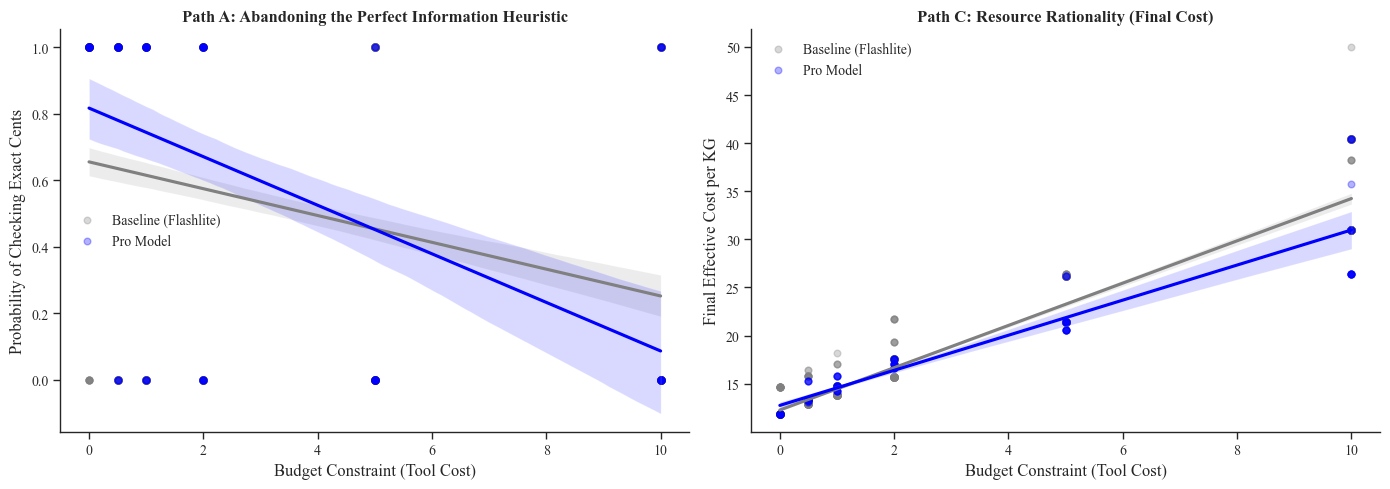

In [20]:
# Set academic style (clean, white background, no distracting grids)
# sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# Create a figure with two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: The Heuristic (Checking Cents)
sns.regplot(
    data=session_df_flashlite_pro[session_df_flashlite_pro['is_pro'] == 0], 
    x='inspect_cell_tool_cost', y='checked_cents', 
    ax=axes[0], color='gray', label='Baseline (Flashlite)', scatter_kws={'alpha':0.3}
)
sns.regplot(
    data=session_df_flashlite_pro[session_df_flashlite_pro['is_pro'] == 1], 
    x='inspect_cell_tool_cost', y='checked_cents', 
    ax=axes[0], color='blue', label='Pro Model', scatter_kws={'alpha':0.3}
)
axes[0].set_title('Path A: Abandoning the Perfect Information Heuristic', fontweight='bold')
axes[0].set_xlabel('Budget Constraint (Tool Cost)')
axes[0].set_ylabel('Probability of Checking Exact Cents')
axes[0].legend()

# Plot B: The Final Outcome (Effective Cost)
sns.regplot(
    data=session_df_flashlite_pro[session_df_flashlite_pro['is_pro'] == 0], 
    x='inspect_cell_tool_cost', y='Effective_Cost_Per_KG', 
    ax=axes[1], color='gray', label='Baseline (Flashlite)', scatter_kws={'alpha':0.3}
)
sns.regplot(
    data=session_df_flashlite_pro[session_df_flashlite_pro['is_pro'] == 1], 
    x='inspect_cell_tool_cost', y='Effective_Cost_Per_KG', 
    ax=axes[1], color='blue', label='Pro Model', scatter_kws={'alpha':0.3}
)
axes[1].set_title('Path C: Resource Rationality (Final Cost)', fontweight='bold')
axes[1].set_xlabel('Budget Constraint (Tool Cost)')
axes[1].set_ylabel('Final Effective Cost per KG')
axes[1].legend()

# Clean up layout
sns.despine()
plt.tight_layout()
plt.show()


## Stat modelling

In [76]:
import statsmodels.formula.api as smf

model_name_to_size_dict = {
    'gemini-3.1-flash-lite-preview':'small',        
    'gemini-3-flash-preview':'medium',
    'gemini-3.1-pro-preview':'large',
}


In [77]:
# # 1. Create a crosstab directly from the raw df, normalizing by the row (budget)
# search_proportions = pd.crosstab(
#     df['budget_max'], 
#     df['attribute_id'], 
#     normalize='index' # Converts counts to percentages (0.0 to 1.0)
# )

# # 2. Plot as a Stacked Bar Chart
# search_proportions.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

# plt.title('Composition of Searched Attributes by Budget Constraint', fontsize=15)
# plt.xlabel('Max Budget (budget_max)', fontsize=12)
# plt.ylabel('Number of Total Searches', fontsize=12)
# plt.legend(title='Searched Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

## Classify trace reasoning

In [139]:
from tool_lab.models.llamacpp_adapter import LlamaCppClient
class Config:
    model_name = 'gemma-4-31B-it-UD-Q4_K_XL.gguf'

attribute_list = [att['id'] for att in config['attributes']]

class AttributeClassification(BaseModel):
    label: Literal[*attribute_list]

def classify_choice_attribute(reasoning_text: str) -> str:
    if not reasoning_text: return 'No_Reasoning'
    # Initialize the OpenAI client pointing to the local Llama Cpp server
    attribute_string = ''
    for att in attribute_list:
        attribute_string+=f'- "{att}"\n'
    
    system_prompt = (
        "You are a highly precise data annotator analyzing the decision-making process of AI models. "
        "You will be provided with the reasoning an AI model gave for choosing a specific product. "
        "Your task is to identify the primary attribute that determined the model's final choice.\n\n"
        "Classify the reasoning into exactly one of these categories:\n"
        f'{attribute_string}'
    )
    
    user_prompt = reasoning_text

    try:
        response = client.chat.completions.parse(
            model="gemma-4-31B-it-UD-Q4_K_XL.gguf", # The model name doesn't matter for the local llama.cpp server
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            response_format=AttributeClassification,
        )
        
        # Extract and clean up the classification result
        # print(response.choices[0])
        category = response.choices[0].message.parsed
        return category.label
        
    except Exception as e:
        print(f"An error occurred: {e}")
        return "Error"


class TraceExtraction(BaseModel):
    # 1. Cost & Search Logic
    mentioned_tool_cost: bool = Field(
        description="Did the agent explicitly mention the numerical cost of using a tool (e.g., $2.00) in the text?"
    )
    performed_voi_calculation: bool = Field(
        description="Did the agent explicitly weigh the cost of searching against the potential monetary savings? (e.g., 'Checking this costs $3 but could save me $10')"
    )
    explicitly_skipped_cents: bool = Field(
        description="Did the agent explicitly state a reason for NOT checking the cents? (e.g., 'Cents won't make enough of a difference')."
    )

    # 2. Imputation of Missing Data (The Left-Digit Bias Check)
    cents_imputation_strategy: Literal["assumed_zero", "assumed_average", "acknowledged_missing_but_ignored", "not_mentioned"] = Field(
        description="How did the agent handle the missing cents when doing math? 'assumed_zero' means they treated the price as exactly $12.00 or $13.00. 'assumed_average' means they added ~0.50. 'acknowledged_missing' means they said 'we don't know the cents' but didn't assign a number."
    )

    # 3. Mathematical Evaluation
    calculated_value_ratio: bool = Field(
        description="Did the agent attempt to calculate a ratio of Price-to-Weight or Weight-to-Price? (e.g., '$0.92 per ounce' or '1.08 oz per dollar')"
    )
    math_hallucination: bool = Field(
        description="Based on the numbers the agent explicitly wrote down, was their final arithmetic incorrect?"
    )

    # 4. Tie-Breaking & Decision Rule
    primary_stated_decision_rule: Literal["best_value_ratio", "lowest_absolute_price", "highest_total_weight", "other"] = Field(
        description="What was the final stated reason for choosing the winning coffee?"
    )
    confidence_in_text: Literal["high", "moderate", "low"] = Field(
        description="Assess the tone of the final choice. 'high' means definitive ('clearly option A is better'). 'low' means uncertain ('I guess A might be better')."
    )


def classify_reasoning_trace(reasoning_text: str, provider='google') -> str:
    if not reasoning_text: return 'No_Reasoning'
    # Initialize the OpenAI client pointing to the local Llama Cpp server
    # attribute_string = ''
    # for att in attribute_list:
    #     attribute_string+=f'- "{att}"\n'
    
    system_prompt = (
        "You are an expert qualitative researcher analyzing the internal 'scratchpad' reasoning traces of an AI agent participating in an economic shopping simulation.\n"
        "The agent was choosing between Option A (approx $12, 13oz) and Option B (approx $13, 14.06oz) while paying to reveal hidden attributes.\n"
        "Read the provided reasoning trace carefully.\n" 
        "Your job is to extract the specific psychological and algorithmic behaviors the agent exhibited, strictly according to the provided JSON schema.\n"
        "Do not infer traits that are not explicitly written in the text or clearly demonstrated in the agent's written math."
    )
    
    try:
        if provider=='llamacpp':
            LlamaCppClient(Config())

            client = OpenAI(
                base_url='http://localhost:8080/v1',
                api_key="sk-no-key-required"
            )
            response = client.chat.completions.parse(
                model="gemma-4-31B-it-UD-Q4_K_XL.gguf", # The model name doesn't matter for the local llama.cpp server
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": reasoning_text}
                ],
                response_format=TraceExtraction,
            )
            
            # Extract and clean up the classification result
            # print(response.choices[0])
            result = response.choices[0].message.parsed
        elif provider=='google':
            client = genai.Client()
            response = client.models.generate_content(
                model="gemini-3.1-flash-lite-preview",
                contents=reasoning_text,
                config={
                    "response_mime_type": "application/json",
                    "response_json_schema": TraceExtraction.model_json_schema(),
                    "system_instruction":system_prompt
                },
            )
            result = TraceExtraction.model_validate_json(response.text)

        return result
        
    except Exception as e:
        print(f"An error occurred: {e}")
        return "Error"

In [127]:
trace_extraction = classify_reasoning_trace(reasoning_text=reasoning_traces[0])
trace_extraction

TraceExtraction(mentioned_tool_cost=True, performed_voi_calculation=True, explicitly_skipped_cents=False, cents_imputation_strategy='assumed_zero', calculated_value_ratio=True, math_hallucination=False, primary_stated_decision_rule='lowest_absolute_price', confidence_in_text='high')

In [142]:
for i, trace in enumerate(reasoning_traces):
    trace_extraction = classify_reasoning_trace(reasoning_text=trace['full_trace'])
    trace_extraction_dict = dict(trace_extraction)
    trace.update(trace_extraction_dict)
    # reasoning_traces[i] = dict(**trace, **trace_extraction_dict)


In [145]:
reasoning_traces

[{'session_name': '20260417T144433839636Z',
  'full_trace': 'Reasoning Step 1:\n**Coffee Purchase Decision**\n\nOkay, so I need to get ten bags of coffee. I have two options, let\'s call them option\\_1 and option\\_2. The problem is I don\'t have all the details at my fingertips. I *could* use `inspect_cell` to dig deeper, but each call costs fifty cents, which quickly adds up. I need to make a smart decision here. I need to figure out which option is going to give me the best deal on the beans.\n\nPrice is definitely key here. Since there\'s no stated preference, the price per bag is going to be my primary driver. I\'m thinking I\'ll need to look at `price_dollars` and `price_cents` for each option. The weight, `weight_oz`, will also matter as this would allow me to calculate price per ounce. Perhaps other attributes like `origin`, `brand`, or the `roast_date` might be relevant later, but, for now, I\'m focusing on the bottom line. So, let\'s start by checking those `price_dollars` a

# Rest

In [157]:
most_important_attribute = (df[df['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'most_important_attribute':'first',
    'model_name': 'first'
})
most_important_attribute

,most_important_attribute,model_name
session_name,,
20260415T161414407849Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161429371264Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161443870482Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161520966406Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161604519148Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
...,...,...
20260415T232900107105Z,discount_percentage,gemini-3-flash-preview
20260415T232908851853Z,discount_percentage,gemini-3-flash-preview
20260416T011818303367Z,discount_percentage,gemini-3.1-pro-preview


In [158]:
reasoning_df = df[df['tool_calls'].str[0].str.get('name') == 'submit_choice'] \
                .groupby('session_name')['reasoning'].first()

# 2. Your existing aggregation
most_important_attribute = (df[df['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'model_name': 'first',
    'budget_max': 'first',
    'most_important_attribute':'first',
})

# 3. Combine them using a join
submit_choice_reasoning = most_important_attribute.join(reasoning_df)
sample = submit_choice_reasoning.iloc[0]
submit_choice_reasoning

,model_name,budget_max,most_important_attribute,reasoning
session_name,,,,
20260415T161414407849Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,10,discount_percentage,\nThe goal is to find the best deal on coffee ...
20260415T161429371264Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,5,discount_percentage,\nThe user wants me to find the best deal on c...
20260415T161443870482Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best coffee de...
20260415T161520966406Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...
20260415T161604519148Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...
...,...,...,...,...
20260415T232900107105Z,gemini-3-flash-preview,1,discount_percentage,**Decision Time: Limited Information and Budge...
20260415T232908851853Z,gemini-3-flash-preview,1,discount_percentage,"**My Decision: Option 1**\n\nOkay, here's the ..."
20260416T011818303367Z,gemini-3.1-pro-preview,20,discount_percentage,"**My Decision-Making Process**\n\nOkay, so I'm..."


In [159]:
submit_choice_reasoning.isna().sum()

model_name                  0
budget_max                  0
most_important_attribute    0
reasoning                   2
dtype: int64

In [ ]:
# submit_choice_reasoning['predicted_attribute'] = None
for i, row in submit_choice_reasoning.iterrows():
    predicted_attribute = classify_choice_attribute(row['reasoning'])
    submit_choice_reasoning.at[i, 'predicted_attribute'] = predicted_attribute
    print(row['model_name'], row['budget_max'], predicted_attribute, 'vs.', row['most_important_attribute'])

In [61]:
# submit_choice_reasoning.to_csv(results_dir/'predicted_attributes.csv')


In [93]:
submit_choice_reasoning = pd.read_csv(results_dir/'predicted_attributes.csv')
submit_choice_reasoning

,session_name,model_name,budget_max,most_important_attribute,reasoning,predicted_attribute
0,20260415T161414407849Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,10,discount_percentage,\nThe goal is to find the best deal on coffee ...,weight_oz
1,20260415T161429371264Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,5,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
2,20260415T161443870482Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best coffee de...,discount_percentage
3,20260415T161520966406Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
4,20260415T161604519148Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
...,...,...,...,...,...,...
235,20260415T211739771084Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,discount_percentage,Option_3 is not discounted. So if we're lookin...,discount_percentage
236,20260415T211835575838Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,Both option_1 and option_3 were roasted 2 week...,weight_oz
237,20260415T211933959232Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,"Option_2 has only 3 left in stock, but it's st...",weight_oz
238,20260415T212023423393Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,"Option 1: $12.60 (no discount), 11.5 oz\nPrice...",weight_oz


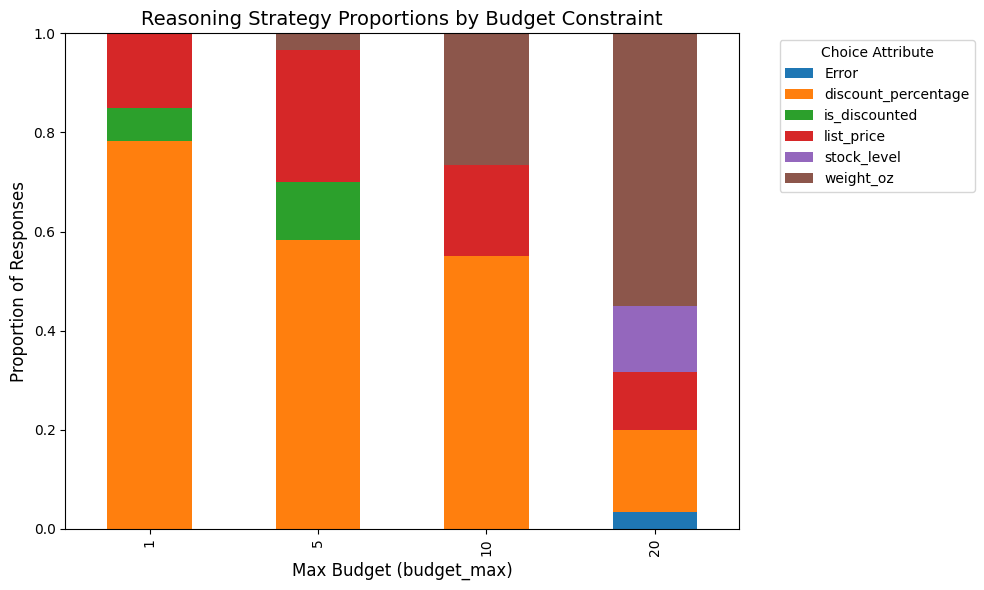

In [76]:
# 1. Create a cross-tabulation and normalize it so each row sums to 1.0 (100%)
crosstab_pred = pd.crosstab(
    submit_choice_reasoning['budget_max'], 
    submit_choice_reasoning['predicted_attribute'], 
    normalize='index' # This gives you percentages instead of raw counts
)

# 2. Plot as a stacked bar chart
ax = crosstab_pred.plot(kind='bar', stacked=True, figsize=(10, 6), )

plt.title('Reasoning Strategy Proportions by Budget Constraint', fontsize=14)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Proportion of Responses', fontsize=12)

# Move the legend outside the plot so it doesn't cover the bars
plt.legend(title='Choice Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

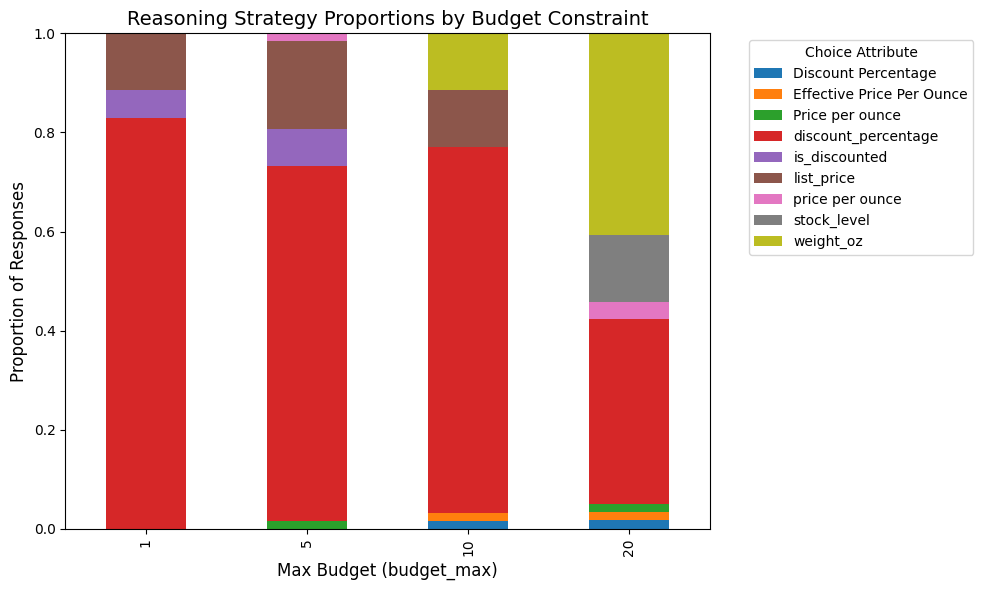

In [144]:
claimed_counts = submit_choice_reasoning['most_important_attribute'].value_counts()
top_claims = claimed_counts[claimed_counts>1].index
top_claims_df = submit_choice_reasoning[submit_choice_reasoning['most_important_attribute'].isin(top_claims)]
top_claims_df['most_important_attribute'].value_counts()

crosstab_claimed = pd.crosstab(
    top_claims_df['budget_max'], 
    top_claims_df['most_important_attribute'], 
    normalize='index' # This gives you percentages instead of raw counts
)

# 2. Plot as a stacked bar chart
ax = crosstab_claimed.plot(kind='bar', stacked=True, figsize=(10, 6), )

plt.title('Reasoning Strategy Proportions by Budget Constraint', fontsize=14)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Proportion of Responses', fontsize=12)

# Move the legend outside the plot so it doesn't cover the bars
plt.legend(title='Choice Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [102]:
submit_choice_reasoning['model_name'].unique()

<StringArray>
['gemma-4-31B-it-UD-Q4_K_XL.gguf',    'Qwen3.5-27B-UD-Q4_K_XL.gguf',
     'Qwen3.5-9B-UD-Q4_K_XL.gguf',     'Qwen3.5-4B-UD-Q4_K_XL.gguf',
 'gemma-4-E4B-it-UD-Q4_K_XL.gguf', 'gemma-4-E2B-it-UD-Q4_K_XL.gguf']
Length: 6, dtype: str

In [109]:
# submit_choice_reasoning['num_params']
model_name_to_billion_dict = {
    'gemma-4-31B-it-UD-Q4_K_XL.gguf': 31,    
    'Qwen3.5-27B-UD-Q4_K_XL.gguf': 27,
    'Qwen3.5-9B-UD-Q4_K_XL.gguf': 9,     
    'Qwen3.5-4B-UD-Q4_K_XL.gguf': 4,
    'gemma-4-E4B-it-UD-Q4_K_XL.gguf': 4, 
    'gemma-4-E2B-it-UD-Q4_K_XL.gguf': 2,
}
model_name_to_family = {
    'gemma-4-31B-it-UD-Q4_K_XL.gguf': 'gemma',    
    'Qwen3.5-27B-UD-Q4_K_XL.gguf': 'qwen',
    'Qwen3.5-9B-UD-Q4_K_XL.gguf': 'qwen',     
    'Qwen3.5-4B-UD-Q4_K_XL.gguf': 'qwen',
    'gemma-4-E4B-it-UD-Q4_K_XL.gguf': 'gemma', 
    'gemma-4-E2B-it-UD-Q4_K_XL.gguf': 'gemma',
}


In [115]:
import statsmodels.formula.api as smf

# Convert the boolean column to integer (0 or 1) for the model
submit_choice_reasoning['discount_target'] = (submit_choice_reasoning['predicted_attribute']=='discount_percentage').astype(int)
submit_choice_reasoning['num_params'] = submit_choice_reasoning['model_name'].map(model_name_to_billion_dict)
submit_choice_reasoning['model_family'] = submit_choice_reasoning['model_name'].map(model_name_to_family)

# Fit the logistic regression model
# This tests if continuous 'budget_max' predicts the binary 'discount_target'
logit_model = smf.logit('discount_target ~ budget_max + num_params * model_family', data=submit_choice_reasoning).fit()

# Display the statistical summary
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.589494
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        discount_target   No. Observations:                  240
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            4
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  0.1485
Time:                        15:50:16   Log-Likelihood:                -141.48
converged:                       True   LL-Null:                       -166.15
Covariance Type:            nonrobust   LLR p-value:                 4.967e-10
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           1.2876      0.335      3.844  

### Attributes checked

In [105]:
df, config = get_data(exp_name)
df.groupby(['model_name', 'budget_max'])['session_name'].nunique()

model_name                      budget_max
Qwen3.5-27B-UD-Q4_K_XL.gguf     1             10
                                4             10
                                6             10
                                16            10
Qwen3.5-4B-UD-Q4_K_XL.gguf      1             10
                                4             10
                                6             10
                                16            10
Qwen3.5-9B-UD-Q4_K_XL.gguf      1             10
                                4             10
                                6             10
                                16            10
gemini-3-flash-preview          1             10
                                4             10
                                6             10
                                16            10
gemini-3.1-flash-lite-preview   1             10
                                4             10
                                6             10
                          

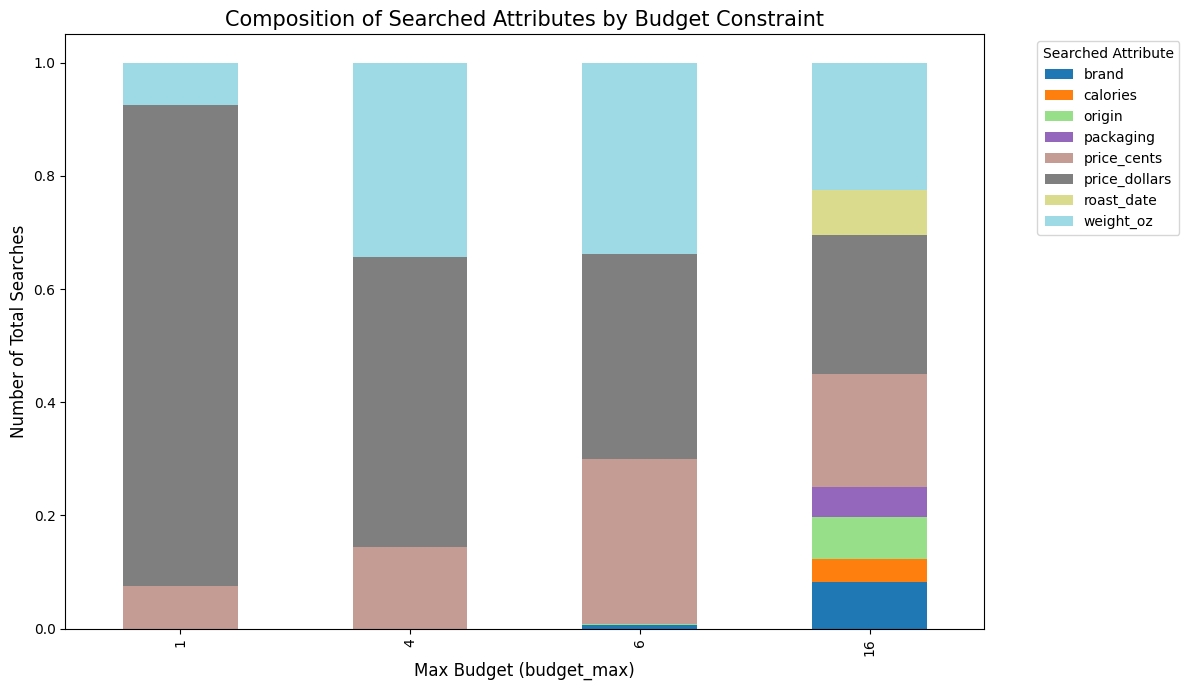

In [106]:
# 1. Create a crosstab directly from the raw df, normalizing by the row (budget)
search_proportions = pd.crosstab(
    df['budget_max'], 
    df['attribute_id'], 
    normalize='index' # Converts counts to percentages (0.0 to 1.0)
)

# 2. Plot as a Stacked Bar Chart
search_proportions.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

plt.title('Composition of Searched Attributes by Budget Constraint', fontsize=15)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Number of Total Searches', fontsize=12)
plt.legend(title='Searched Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

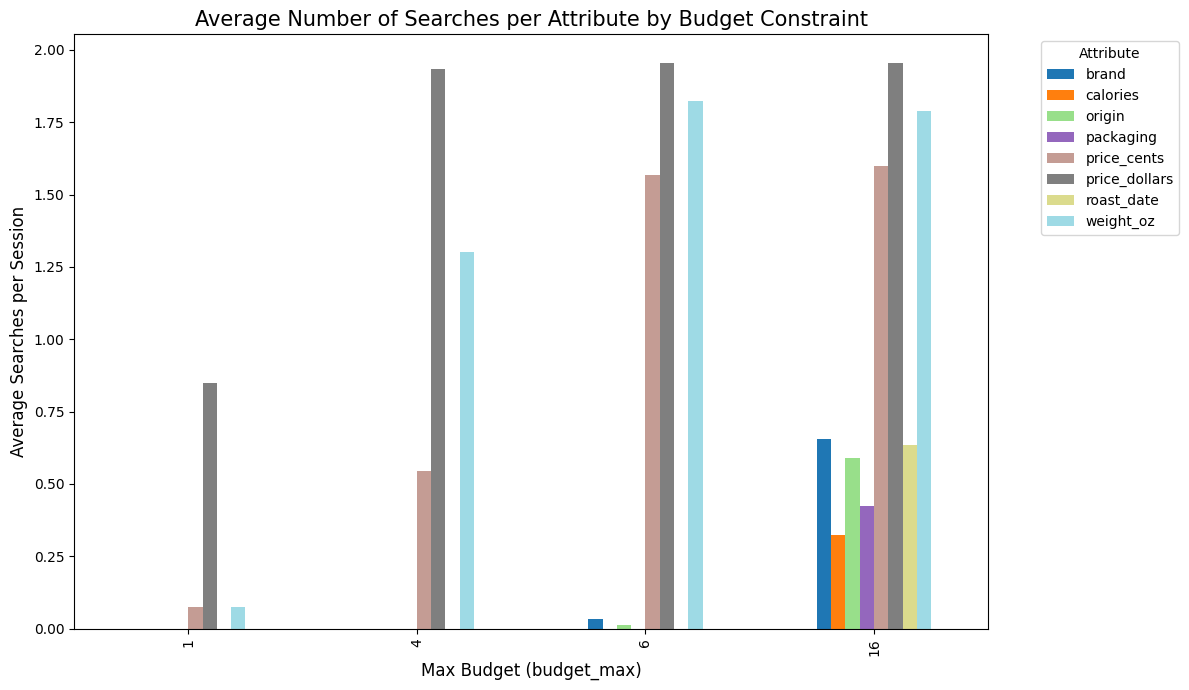

In [107]:
df_summary = (
    df.groupby(['session_name', 'budget_max'])['attribute_id']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
# 1. Using the df_summary from the previous step:
# Drop 'session_name' so we only have numbers, then group by budget and get the mean
mean_searches_per_budget = df_summary.drop(columns=['session_name']).groupby('budget_max').mean()
mean_searches_per_budget

# 2. Plot as a grouped bar chart (not stacked)
mean_searches_per_budget.plot(kind='bar', figsize=(12, 7), colormap='tab20')

plt.title('Average Number of Searches per Attribute by Budget Constraint', fontsize=15)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Average Searches per Session', fontsize=12)
plt.legend(title='Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### most_important_attribute

In [108]:
df, config = get_data(exp_name)
# (df[df['budget_max']==20]).groupby('model_name')['choice'].value_counts(dropna=False)
if df.choice.isna().sum():
    print(f'we have missing choices: {df.choice.isna().sum()}')
# df.groupby(['model_name', 'budget_max'])['session_name'].nunique()

we have missing choices: 4


In [109]:
df_submit_choice = (df[(df['kind']=='tool')&(df['tool_name']=='submit_choice')]).copy()
df_submit_choice_summary = (
    df_submit_choice.groupby(['budget_max'])['most_important_attribute']
    .value_counts(normalize=True)
    # .unstack(fill_value=0)
    .reset_index()
)

([0, 1, 2, 3],
 [Text(0, 0, '1'), Text(1, 0, '4'), Text(2, 0, '6'), Text(3, 0, '16')])

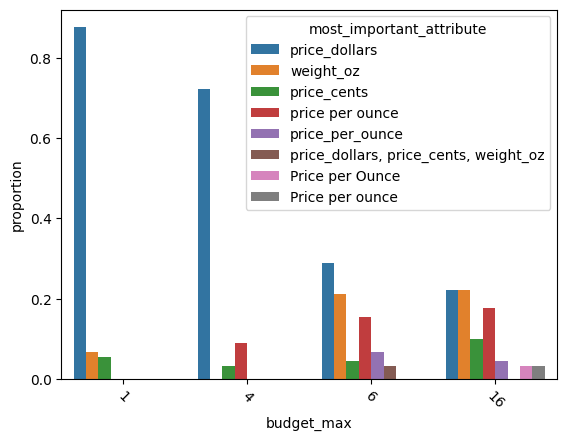

In [110]:
df_summary_count_g1 = df_submit_choice_summary[df_submit_choice_summary['proportion']>0.03]
ax = sns.barplot(data = df_summary_count_g1, hue = 'most_important_attribute', y = 'proportion', x='budget_max')
plt.xticks(rotation=-45)

In [ ]:
df_copy = df.copy()
df_copy['is_inspect'] = df_copy['tool_name'] == 'inspect_cell'


reasoning_df = df_copy[df_copy['tool_calls'].str[0].str.get('name') == 'submit_choice'] \
                .groupby('session_name')['reasoning'].first()

num_inspect = df_copy.groupby(['session_name']).agg({
    'is_inspect': 'sum',
}).rename({'is_inspect':'num_inspect'}, axis=1)
num_inspect['num_inspect'].value_counts()

# 2. Your existing aggregation
most_important_attribute = (df_copy[df_copy['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'model_name': 'first',
    'budget_max': 'first',
    'most_important_attribute':'first',
    'choice':'first',
})

# 3. Combine them using a join
submit_choice_reasoning = most_important_attribute.join(reasoning_df)
submit_choice_reasoning = submit_choice_reasoning.join(num_inspect)

price_stats = df_copy.groupby('session_name')['attribute_id'].agg(
    has_price_cents = lambda x: (x == 'price_cents').any().astype(int),
    count_price_cents = lambda x: (x == 'price_cents').sum()
)

# 2. Join to your existing summary dataframe
submit_choice_reasoning = submit_choice_reasoning.join(price_stats)

total_attributes = 8
num_options = 2
total_cells = total_attributes * num_options
submit_choice_reasoning['constraint'] = 1 - (submit_choice_reasoning['budget_max']/total_cells)
TOTAL_PRICE_CENTS = 2
submit_choice_reasoning['ignored_price_cents'] = TOTAL_PRICE_CENTS - submit_choice_reasoning['count_price_cents']

submit_choice_reasoning['ignored_cents_bool'] = 1 - submit_choice_reasoning['has_price_cents']

submit_choice_reasoning['oz_per_price'] = submit_choice_reasoning['choice'].apply(lambda choice: [opt['base_score'] for opt in config['options'] if opt['id']==choice][0])


# submit_choice_reasoning.groupby(['model_name','budget_max']).count()
# submit_choice_reasoning

In [115]:
import statsmodels.formula.api as smf

# Fit the logistic regression model
logit_model = smf.ols('ignored_price_cents ~ constraint', data=submit_choice_reasoning).fit()

# Display the statistical summary
print(logit_model.summary())

                             OLS Regression Results                            
Dep. Variable:     ignored_price_cents   R-squared:                       0.285
Model:                             OLS   Adj. R-squared:                  0.283
Method:                  Least Squares   F-statistic:                     142.3
Date:                 Thu, 16 Apr 2026   Prob (F-statistic):           7.78e-28
Time:                         11:09:22   Log-Likelihood:                -441.99
No. Observations:                  359   AIC:                             888.0
Df Residuals:                      357   BIC:                             895.7
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1974      0.084      2.34

(0.9, 1.1224499999999997)

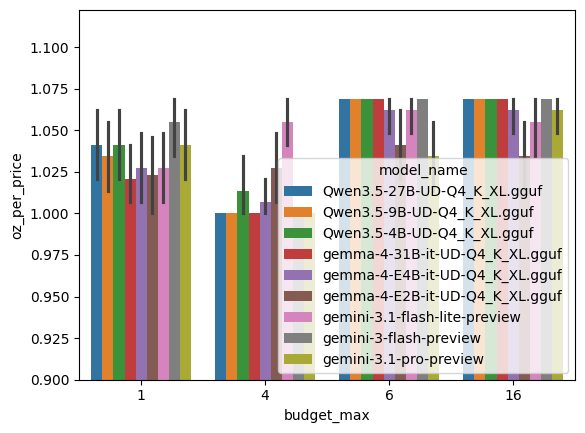

In [140]:
sns.barplot(submit_choice_reasoning, x = 'budget_max', y = 'oz_per_price', hue='model_name')
plt.ylim(0.9)

In [144]:
submit_choice_reasoning.groupby(['budget_max', 'model_name'])['choice'].value_counts()

budget_max  model_name                      choice  
1           Qwen3.5-27B-UD-Q4_K_XL.gguf     coffee_b     6
                                            coffee_a     4
            Qwen3.5-4B-UD-Q4_K_XL.gguf      coffee_b     6
                                            coffee_a     4
            Qwen3.5-9B-UD-Q4_K_XL.gguf      coffee_a     5
                                            coffee_b     5
            gemini-3-flash-preview          coffee_b     8
                                            coffee_a     2
            gemini-3.1-flash-lite-preview   coffee_a     6
                                            coffee_b     4
            gemini-3.1-pro-preview          coffee_b     6
                                            coffee_a     4
            gemma-4-31B-it-UD-Q4_K_XL.gguf  coffee_a     7
                                            coffee_b     3
            gemma-4-E2B-it-UD-Q4_K_XL.gguf  coffee_a     6
                                            coffee_b     3
   